# code for topic modeling of episode annotations and recall transcripts

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist
from scipy.signal import resample
from scipy.interpolate import interp1d

%matplotlib inline

### paths

In [2]:
data_dir = '../../data'
annot_dir = f'{data_dir}/annotations_dfs/'
transc_dir = f'{data_dir}/transcriptions/automatic/'
ep_traj_dir = f'{data_dir}/models/episodes/trajectories/'
rec_traj_dir = f'{data_dir}/models/participants/trajectories/'
pickle_dir = f'{data_dir}/pickles/'

### load formatted annotations

In [3]:
atlep1_df = pd.read_csv(annot_dir+'atlep1.csv')
atlep2_df = pd.read_csv(annot_dir+'atlep2.csv')
arrdev_df = pd.read_csv(annot_dir+'arrdev.csv')

### topic modeling parameters

In [4]:
n_topics = 100
episode_wsize = 50
recall_wsize = 200

# vectorizer parameters
vectorizer_params = {
    'model' : 'CountVectorizer', 
    'params' : {
        'stop_words' : 'english'
    }
}

# topic model parameters
semantic_params = {
    'model' : 'LatentDirichletAllocation', 
    'params' : {
        'n_components' : n_topics,
        'learning_method' : 'batch',
        'random_state' : 0,
    }
}

## functions

### for creating episode/recall sliding windows

In [5]:
def format_episode_text(textlist):
    """
    standardize annotation text format for modeling
    """
    formatted = []
    for chunk in textlist:
        lower_nopunc = re.sub("[^\w\s-]+", '', chunk.lower())    # remove all punctuation except for dashes
        no_acc = lower_nopunc.replace('É', 'E')    # remove accented characters
        no_digit = re.sub(r"(\d+)", lambda x: num2words(int(x.group(0))), no_acc)    # convert digits to words
        spaced = ' '.join(no_digit.replace(',', ' ').split())    # deal with inconsistent whitespace
        formatted.append(spaced)
    
    return formatted

In [6]:
def get_episode_windows(episode_df, episode_wsize=episode_wsize):
    # throw all annotations into "bag of words"
    episode_bag = format_episode_text(episode_df.loc[:,'Narrative details (external events)':'Setting'].apply(
        lambda x: ', '.join(x.fillna('')), axis=1).values.tolist())
    # create sliding windows
    episode_w = []
    for idx, sentence in enumerate(episode_bag):
        episode_w.append(' '.join(episode_bag[idx:idx+episode_wsize]))

    return episode_w

In [7]:
def get_recall_windows(transcript, recall_wsize=recall_wsize):
    rec_list = transcript.split()
    # create sliding windows
    recall_w = []
    for ix, word in enumerate(rec_list):
        recall_w.append(' '.join(rec_list[ix:ix+recall_wsize]))
        
    return recall_w

### for interpolating episode trajectories

In [8]:
def find_midpoint_time(df):
    """
    returns list of timepoints at middle of each annotation segment
    """
    # use timestamp of last frame from episode to find midpoint of last annotation
    df_shapes = [atlep1_df.shape, atlep2_df.shape, arrdev_df.shape]
    endframe_times = [1466.0, 1316.52, 1236.6]
    endframe_time = endframe_times[df_shapes.index(df.shape)]

    midpoint_times = []
    for i, tpt in enumerate(df['Onset time']):
        try:
            midpoint_times.append((tpt + df['Onset time'][i+1]) / 2)
#             midpoint_times.append(np.mean([tpt, df['Onset time'][i+1]]))
        except KeyError:    # handle last annotation
            midpoint_times.append((tpt + endframe_time) / 2)
#             midpoint_times.append(np.mean([tpt, endframe_time]))
                    
    return midpoint_times, endframe_time

In [9]:
def interpolate_episode(traj, df, resolution=1):
    """
    uses linear interpolation to resample episode trajectory timeseries to desired resolution. 
    'resolution' is in units of seconds.
    """
    # get middle timepoint for each annotation
    midpoint_times, endframe_time = find_midpoint_time(df)
    new_traj = np.arange(int(round(endframe_time)), step=resolution)
    interp_func = interp1d(midpoint_times, traj, axis=0, fill_value='extrapolate')
    
    return interp_func(new_traj)

## main topic modeling function

In [10]:
def fit_and_transform(documents, vec_params=vectorizer_params, sem_params=semantic_params, 
                        corpus=None, resample_shape=None, return_windows=False):
    # handle annotations
    if isinstance(documents, pd.DataFrame):
        windows = get_episode_windows(documents, episode_wsize)
        corpus = windows if not corpus else corpus
        # fit topic model and transform documents
        traj =  hyp.tools.format_data(windows, vectorizer=vec_params, semantic=sem_params, corpus=corpus)[0]
        
        # interpolate to length of episode (seconds)
        if return_windows:
            return interpolate_episode(traj, documents), windows
        else:
            return interpolate_episode(traj, documents)
        
    # handle recall transcripts
    elif isinstance(documents, str):
        if not corpus:
            raise ValueError("You must pass a training corpus to transform recall transcripts")
        windows = get_recall_windows(documents, recall_wsize)
        traj =  hyp.tools.format_data(windows, vectorizer=vec_params, semantic=sem_params, corpus=corpus)[0]
        
        # resample to corresponding episode length
        return resample(traj, resample_shape) 

## model episode content, get sliding windows for fitting recall models

In [11]:
atlep1_traj, atlep1_windows = fit_and_transform(atlep1_df, return_windows=True)
atlep2_traj, atlep2_windows = fit_and_transform(atlep2_df, return_windows=True)
arrdev_traj, arrdev_windows = fit_and_transform(arrdev_df, return_windows=True)

## save episode trajectories/load saved trajectories

In [12]:
np.save(os.path.join(ep_traj_dir, 'atlep1_trajectory'), atlep1_traj)
np.save(os.path.join(ep_traj_dir, 'atlep2_trajectory'), atlep2_traj)
np.save(os.path.join(ep_traj_dir, 'arrdev_trajectory'), arrdev_traj)

# atlep1_traj = np.load(os.path.join(ep_traj_dir, 'atlep1_trajectory.npy'))
# atlep2_traj = np.load(os.path.join(ep_traj_dir, 'atlep2_trajectory.npy'))
# arrdev_traj = np.load(os.path.join(ep_traj_dir, 'arrdev_trajectory.npy'))

## load in and model recall transcripts

In [17]:
participant_trajectories = {
    'atlep1' : [],
    'prediction' : [],
    'delayed' : [],
    'atlep2' : [],
    'arrdev' : []
}

total = sum([len([f for f in files if f.endswith('corrected.wav.txt')]) for r, d, files in os.walk(transc_dir)])
# walk transcription directory structure
currfile = 1
for root, dirs, files in os.walk(transc_dir):
    
    # FOR USE WITH AUTOMATIC TRANSCRIPTS -- REMOVE WHEN SWITCHING TO MANUAL
    transcripts = [f for f in files if f.endswith('corrected.wav.txt')]
    for transc in transcripts:

        # assign correct episode windows, corresponding episode trajectory shape, and dict key
        if any('prediction' in t for t in transcripts) or 'delayed' in transc:
            corpus = atlep1_windows
            resample_shape = atlep1_traj.shape[0]
            if 'recall' in transc:
                rectype = 'atlep1'
            elif 'prediction' in transc:
                rectype = 'prediction'
            elif 'delayed' in transc:
                rectype = 'delayed'
            else:
                raise ValueError('Transcript is not a recognized option')
            
        elif '-A-' in root:
            corpus = atlep2_windows
            resample_shape = atlep2_traj.shape[0]
            rectype = 'atlep2'
            
        else:
            corpus = arrdev_windows
            resample_shape = arrdev_traj.shape[0]
            rectype = 'arrdev'
            
        with open(os.path.join(root,transc), 'r') as f:
            transcript = ' '.join([line.split(',')[0] for line in f.read().split('\n')])
            
        print(f'processing transcript {currfile}/{total}...')    
        p_traj = model_and_transform(transcript, resample_shape=resample_shape, corpus=corpus, 
                                     sem_params=semantic_params)
        
        participant_trajectories[rectype].append((transc.split('-')[0],p_traj))
        currfile += 1

## save trajectories, load in later

In [19]:
# with open(pickle_dir+'/participant_models.p', 'wb') as f:
#     pickle.dump(participant_trajectories, f)

# with open(pickle_dir+'/participant_models_vidwProp.p', 'wb') as f:
#     pickle.dump(participant_trajectories, f)

# with open(pickle_dir+'/participant_models_vidwProp_recwProp.p', 'wb') as f:
#     pickle.dump(participant_trajectories, f)

In [20]:
# for rectype, data in participant_trajectories.items():
#     for (turkid, traj) in data:
#         np.save(os.path.join(rec_traj_dir,rectype,turkid+'.npy'), traj)

# for rectype, data in participant_trajectories.items():
#     for (turkid, traj) in data:
#         np.save(os.path.join(rec_traj_dir,'vidwProp',rectype,turkid+'.npy'), traj)

# for rectype, data in participant_trajectories.items():
#     for (turkid, traj) in data:
#         np.save(os.path.join(rec_traj_dir,'vidwProp_recwProp',rectype,turkid+'.npy'), traj)

In [3]:
with open(pickle_dir+'/participant_models.p', 'rb') as f:
    participant_trajectories = pickle.load(f)
    
# with open(pickle_dir+'/participant_models_vidwProp.p', 'rb') as f:
#     participant_trajectories = pickle.load(f)

# with open(pickle_dir+'/participant_models_vidwProp_recwProp.p', 'rb') as f:
#     participant_trajectories = pickle.load(f)

In [4]:
participant_trajectories

{'arrdev': [('debugW3qVn:debugxspIb',
   array([[ 2.46725252e-04, -4.17390950e-04,  3.44667008e-04, ...,
            4.09872661e-02,  2.46725252e-04,  2.46725252e-04],
          [ 1.37756954e-04,  8.13537135e-04,  3.98122396e-05, ...,
           -2.66838849e-02,  1.37756954e-04,  1.37756954e-04],
          [ 1.61454162e-04, -5.27467112e-04,  2.59402169e-04, ...,
            2.15785233e-02,  1.61454162e-04,  1.61454162e-04],
          ...,
          [ 2.23121960e-03,  2.86789130e-03,  2.13328474e-03, ...,
            7.35561351e-01,  2.23121960e-03,  2.23121960e-03],
          [ 4.70478124e-03,  4.06010840e-03,  4.80271807e-03, ...,
            5.61725457e-01,  4.70478124e-03,  4.70478124e-03],
          [ 5.14139743e-03,  5.79518454e-03,  5.04345830e-03, ...,
            4.75550766e-01,  5.14139743e-03,  5.14139743e-03]])),
  ('debugOAHPU:debugIjGSz',
   array([[ 9.20005638e-04,  2.04060993e-02,  1.00523811e-03, ...,
            2.21625750e-04,  9.20005638e-04,  9.20005638e-04],
      

## create average participant trajectories

In [41]:
avg_trajectories = dict.fromkeys(participant_trajectories.keys())

for rectype, data in participant_trajectories.items():
    avg_trajectories[rectype] = np.mean(np.array([traj for (turkid, traj) in data]), axis=0)
    
#     np.save(os.path.join(rec_traj_dir,rectype,'avg_trajectory.npy'), avg_trajectories[rectype])
    
#     np.save(os.path.join(rec_traj_dir,'vidwProp',rectype,'avg_trajectory.npy'), avg_trajectories[rectype])
    
#     np.save(os.path.join(rec_traj_dir,'vidwProp_recwProp',rectype,'avg_trajectory.npy'), avg_trajectories[rectype])

# some plots

## average participant trajectory vs corresponding episode trajectory

atlep1:


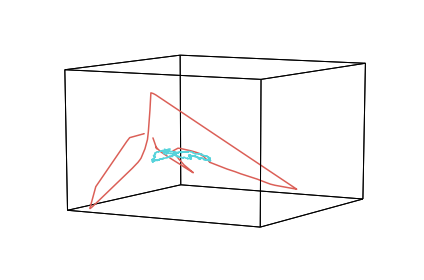

prediction:


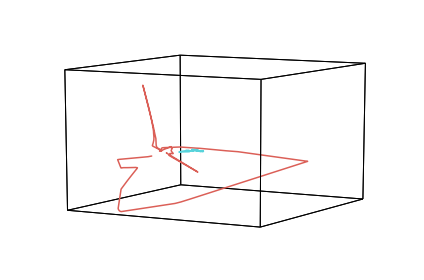

delayed:


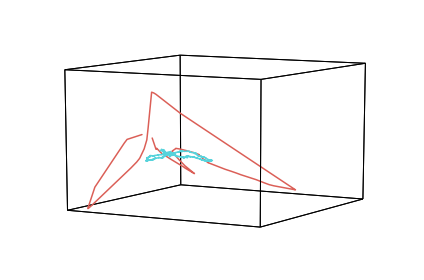

atlep2:


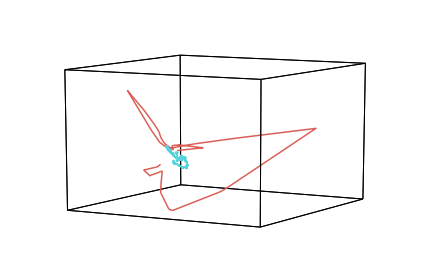

arrdev:


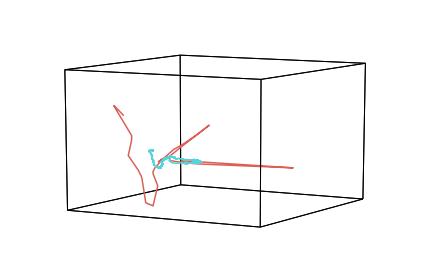

In [30]:
# old parameters
for rectype, avg_traj in avg_trajectories.items():
    if rectype in ['atlep2', 'prediction']:
        ep_traj = atlep2_traj
    elif rectype == 'arrdev':
        ep_traj = arrdev_traj
    else:
        ep_traj = atlep1_traj
        
    print(rectype+':')    
    hyp.plot([ep_traj, avg_traj])

In [31]:
# # updated episode wsize
# for rectype, avg_traj in avg_trajectories.items():
#     if rectype in ['atlep2', 'prediction']:
#         ep_traj = atlep2_traj_prop
#     elif rectype == 'arrdev':
#         ep_traj = arrdev_traj_prop
#     else:
#         ep_traj = atlep1_traj_prop
        
#     print(rectype+':')    
#     hyp.plot([ep_traj, avg_traj])

In [32]:
# # updated episode wsize and recall wsize
# for rectype, avg_traj in avg_trajectories.items():
#     if rectype in ['atlep2', 'prediction']:
#         ep_traj = atlep2_traj_prop
#     elif rectype == 'arrdev':
#         ep_traj = arrdev_traj_prop
#     else:
#         ep_traj = atlep1_traj_prop
        
#     print(rectype+':')    
#     hyp.plot([ep_traj, avg_traj])

## individual participant trajectories vs episode trajectory

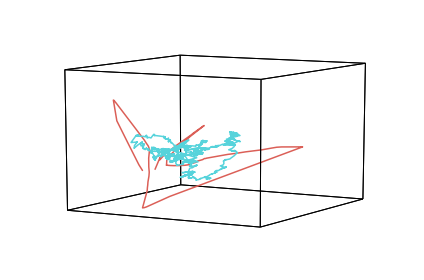

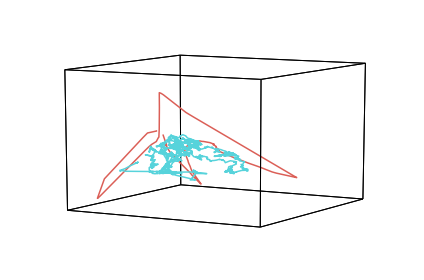

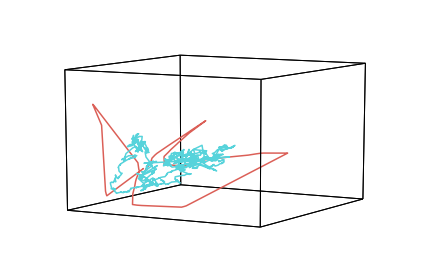

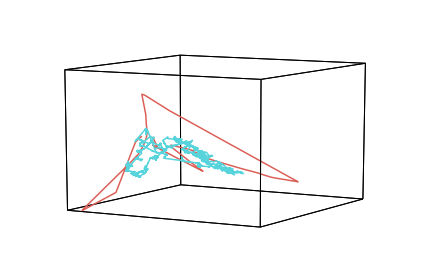

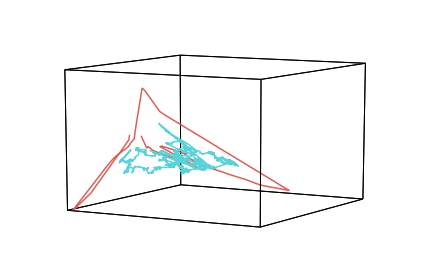

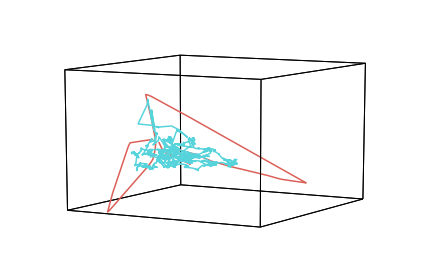

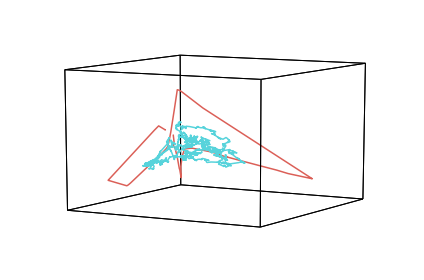

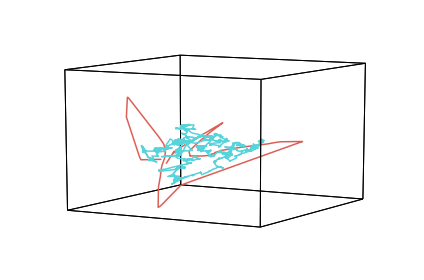

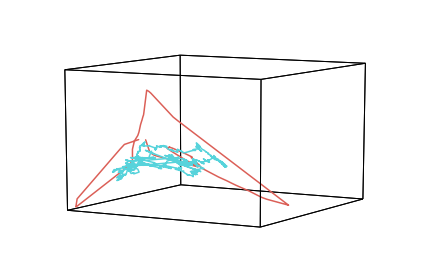

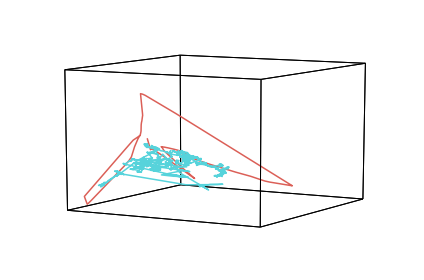

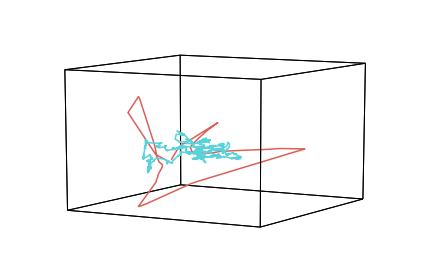

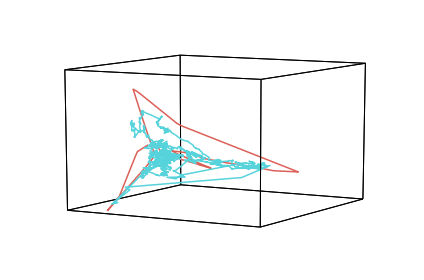

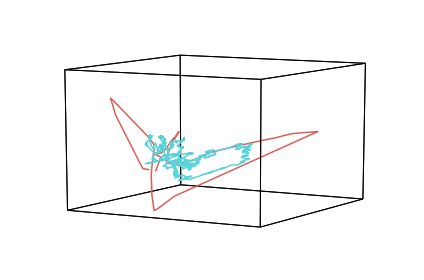

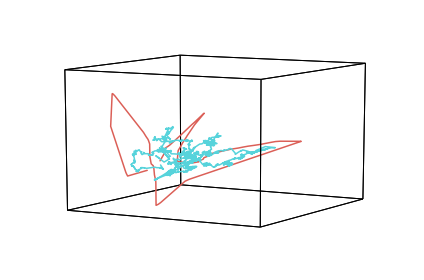

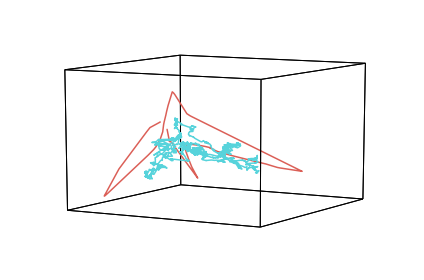

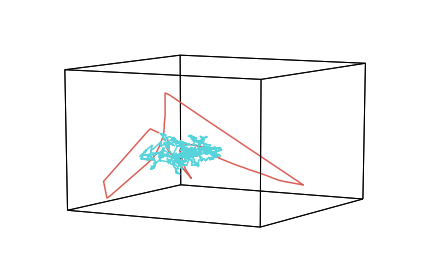

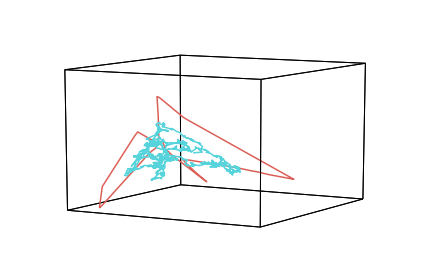

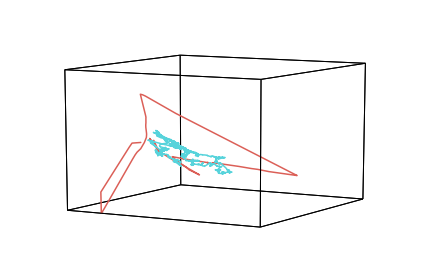

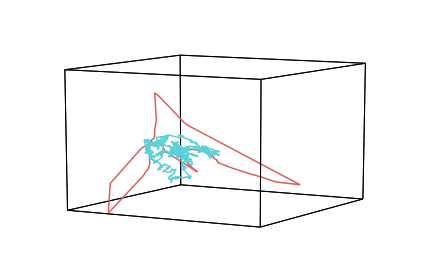

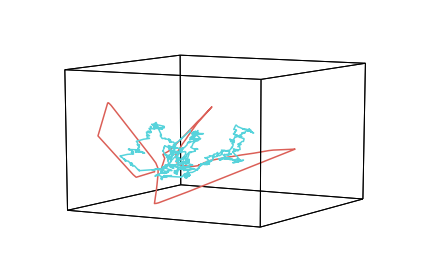

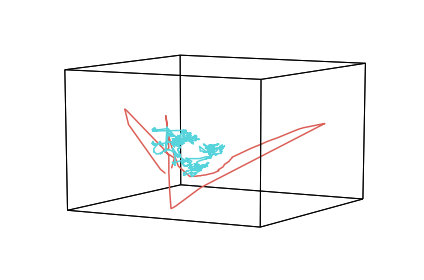

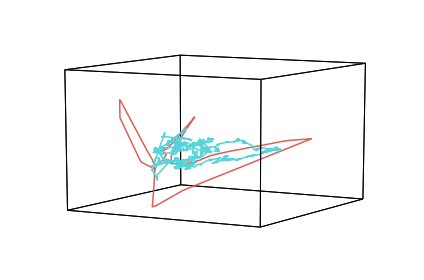

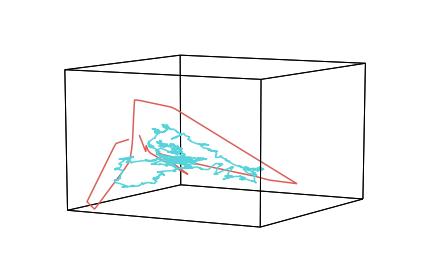

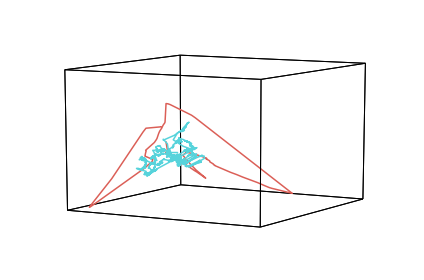

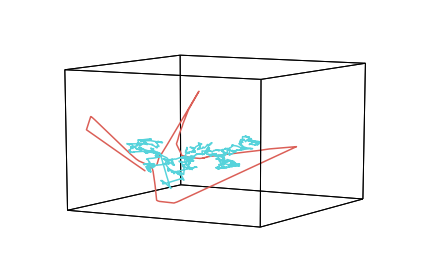

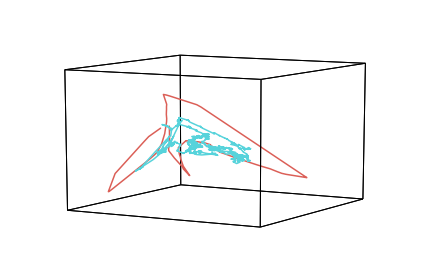

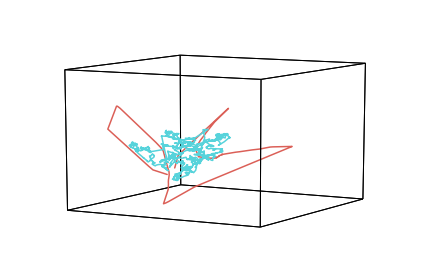

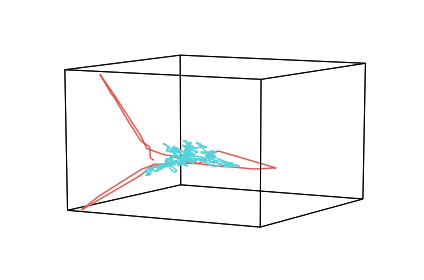

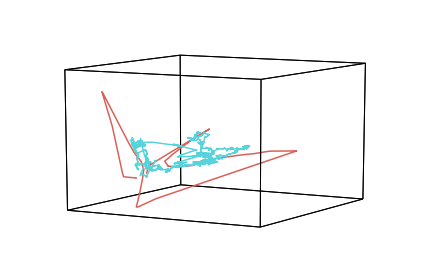

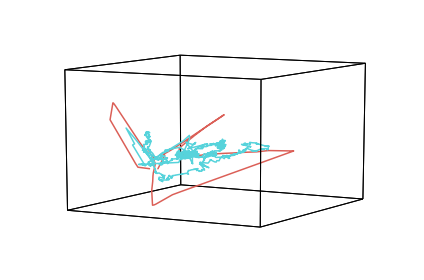

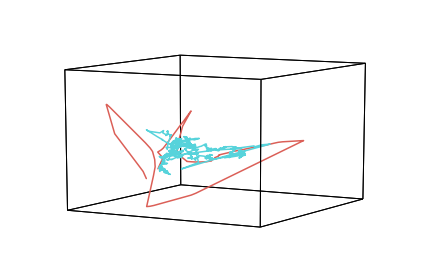

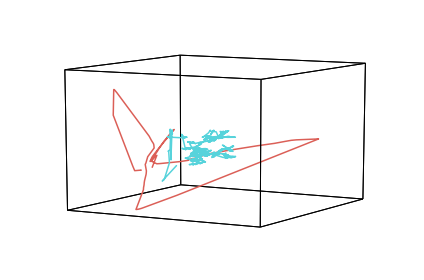

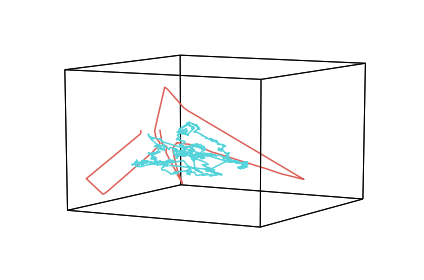

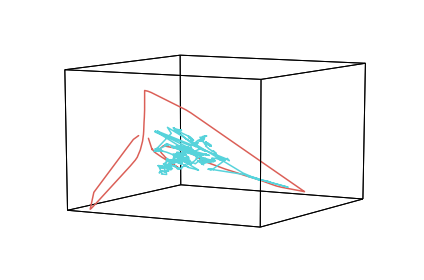

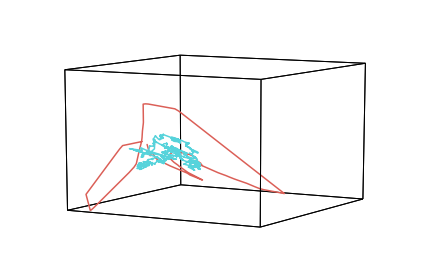

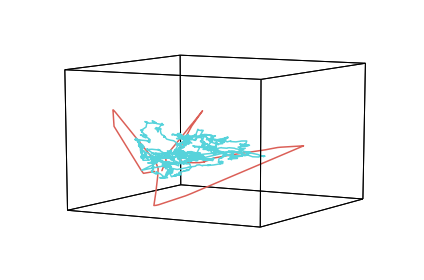

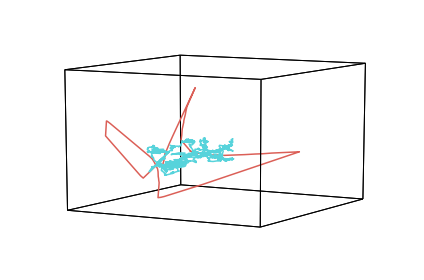

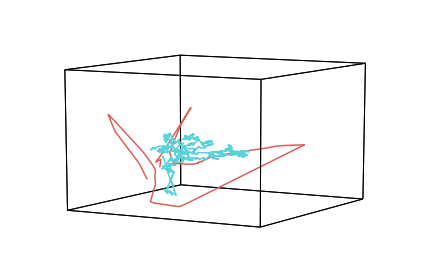

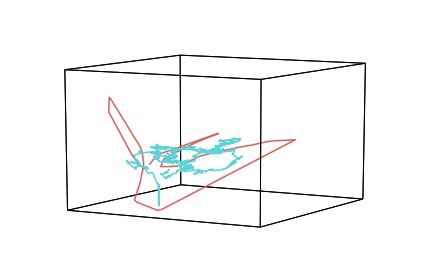

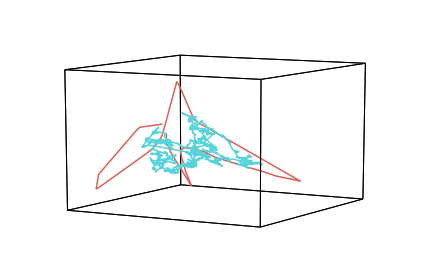

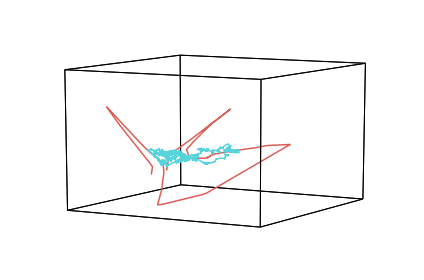

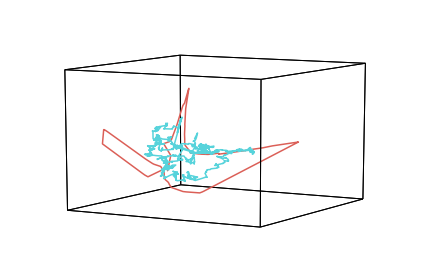

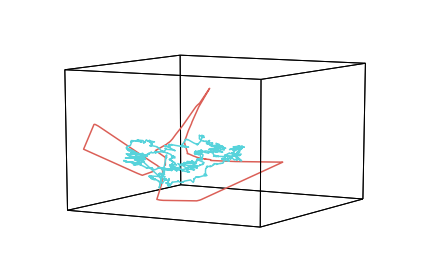

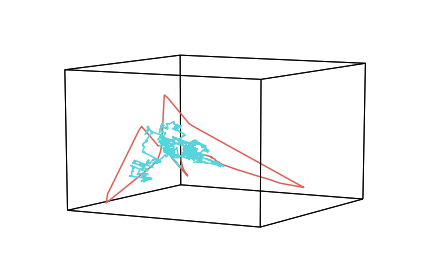

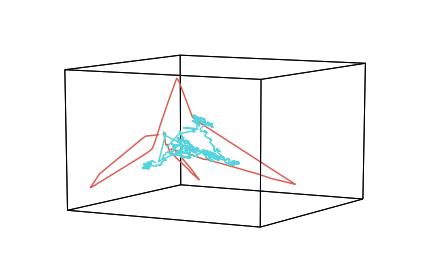

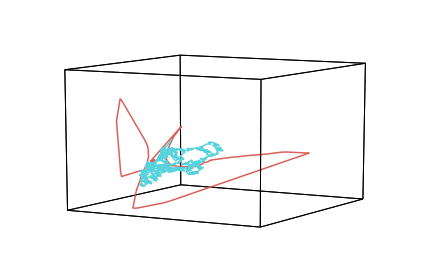

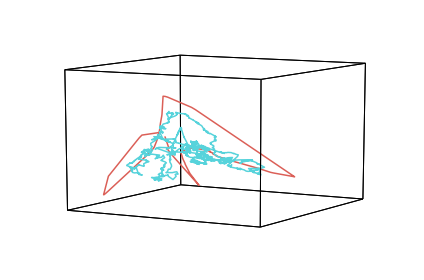

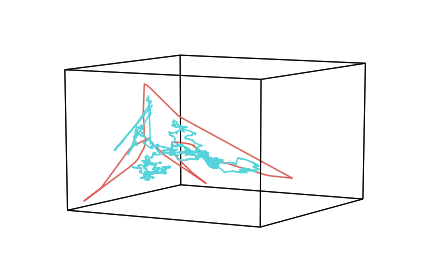

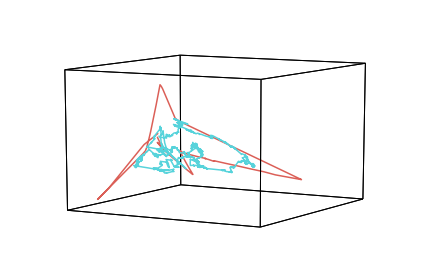

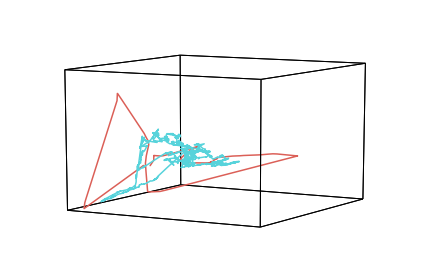

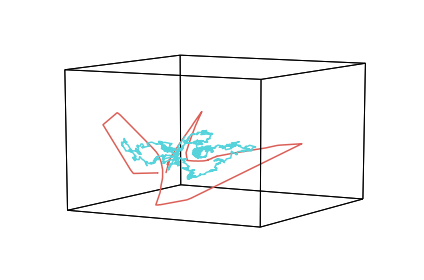

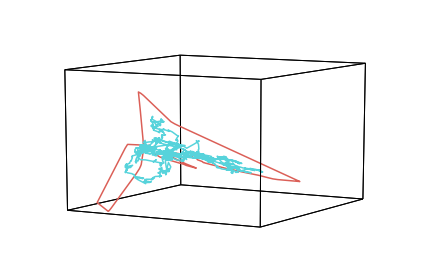

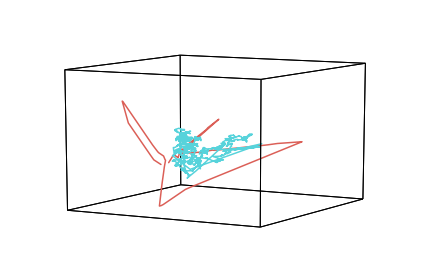

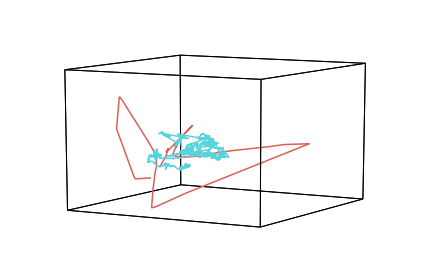

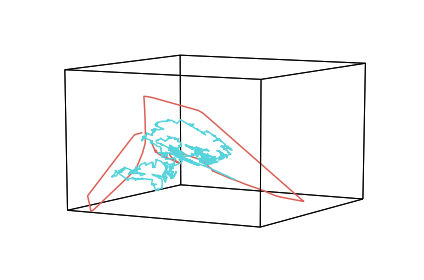

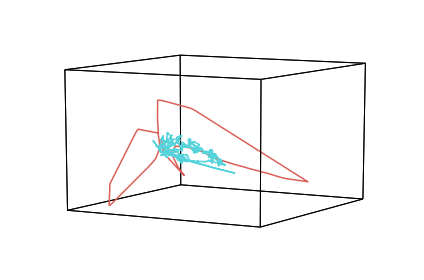

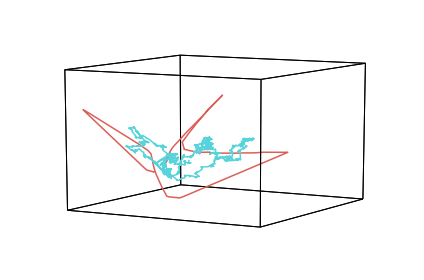

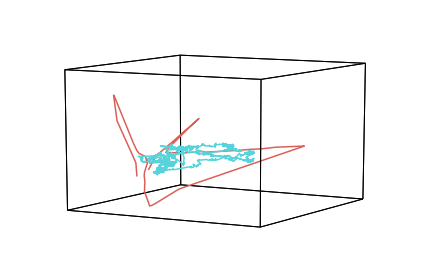

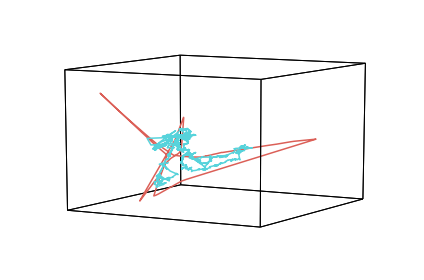

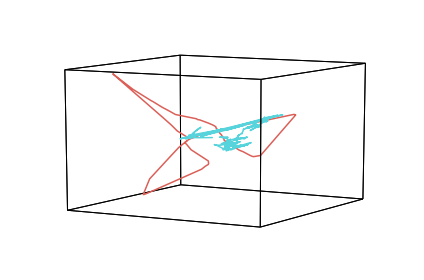

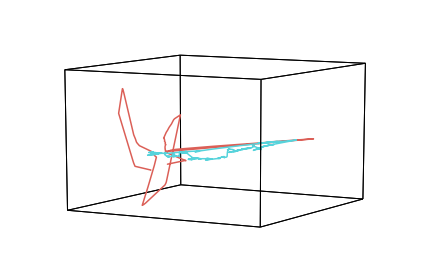

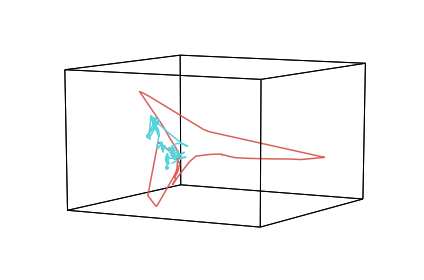

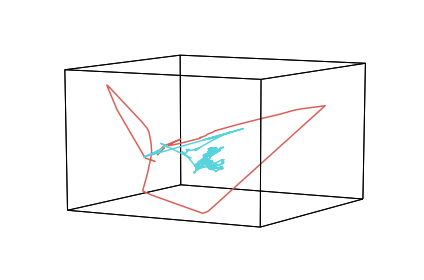

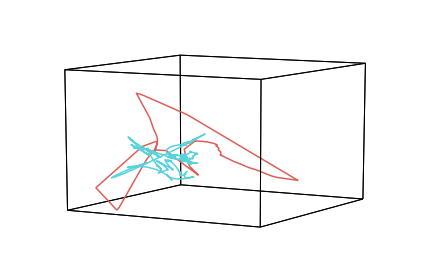

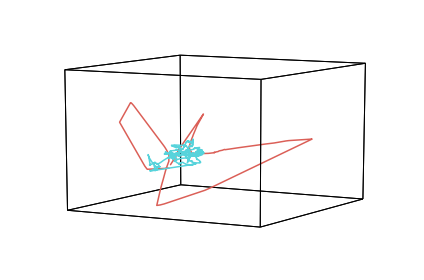

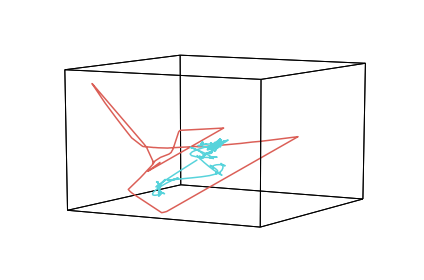

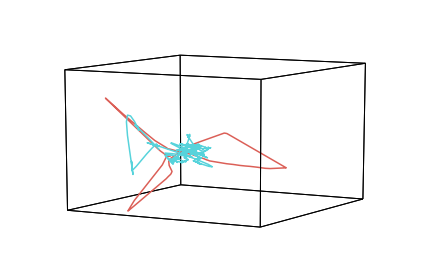

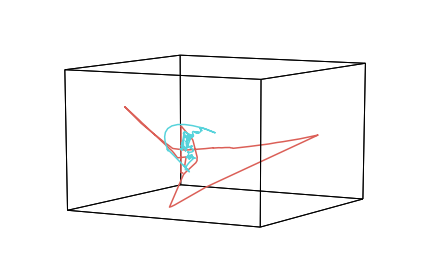

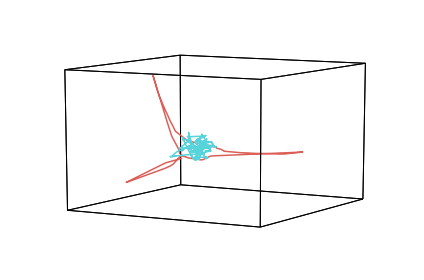

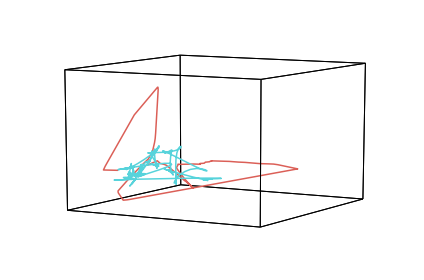

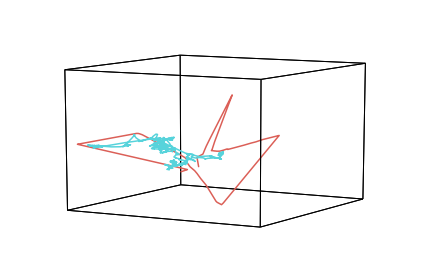

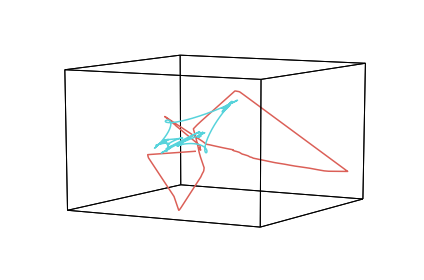

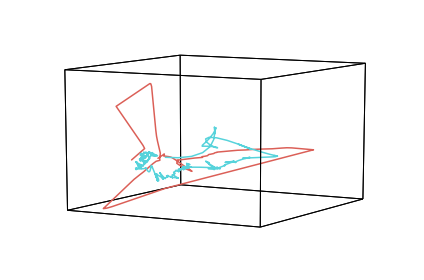

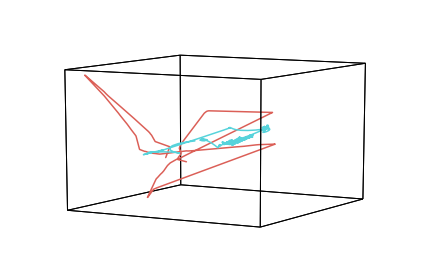

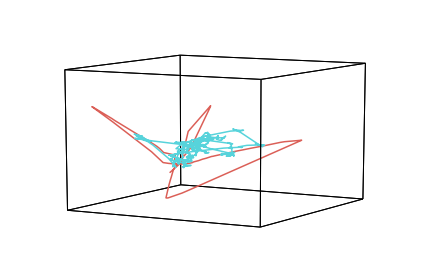

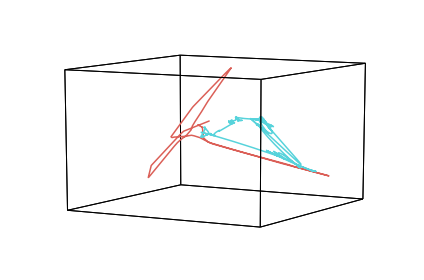

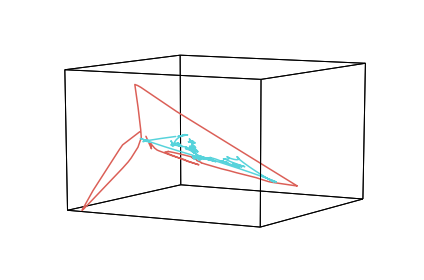

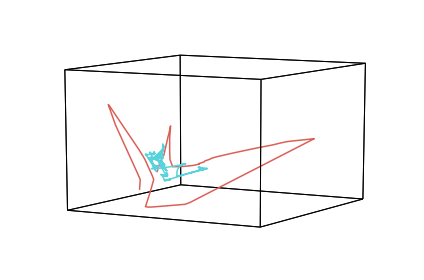

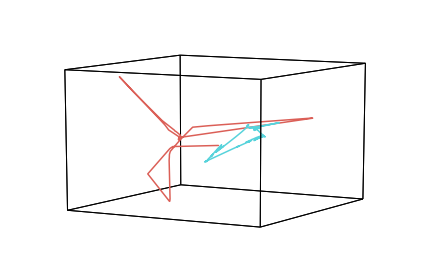

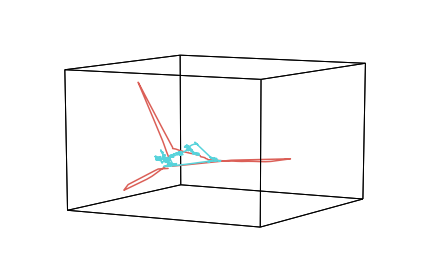

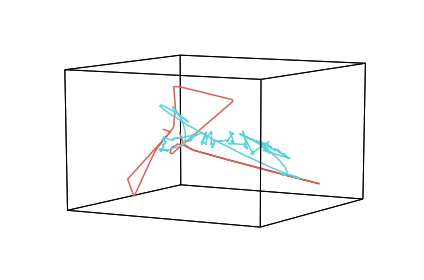

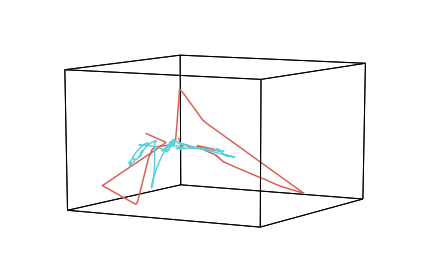

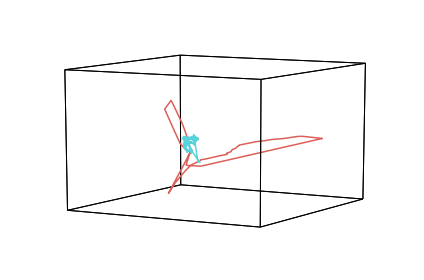

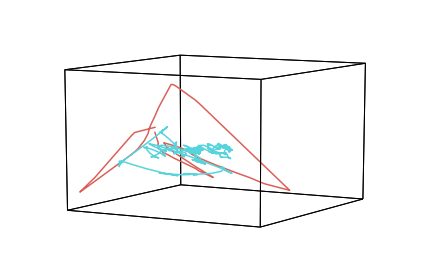

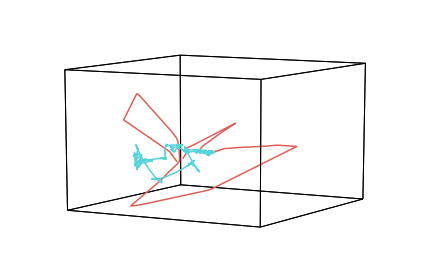

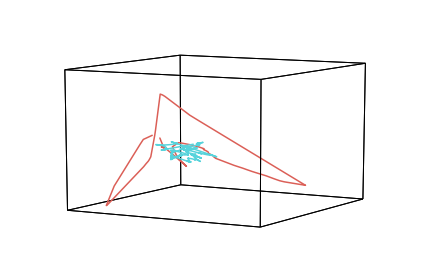

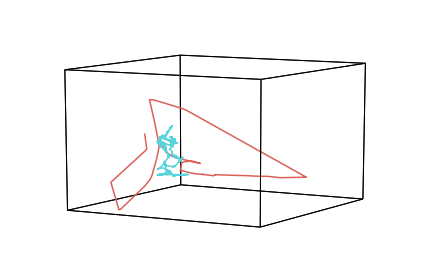

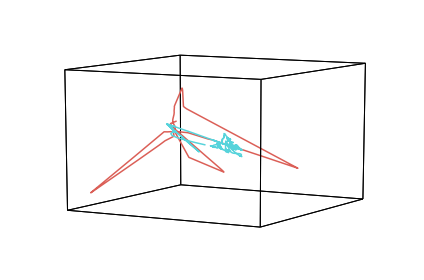

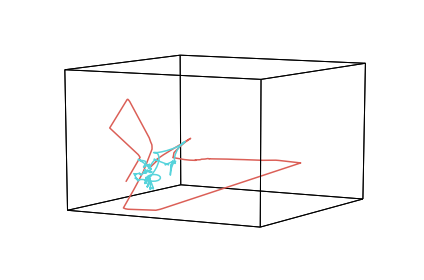

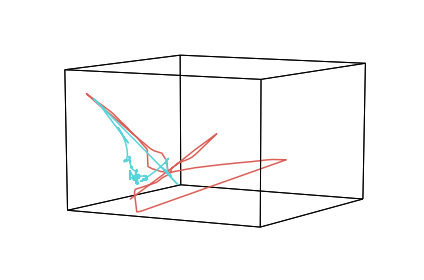

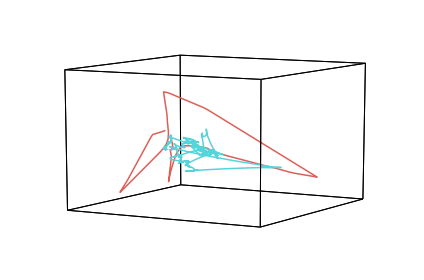

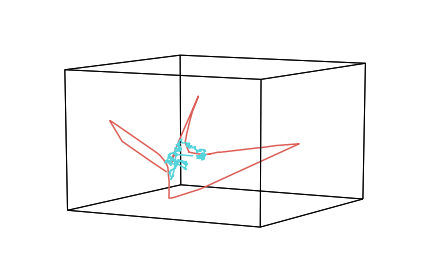

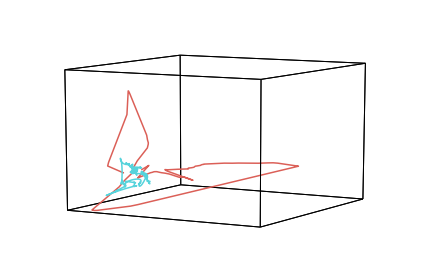

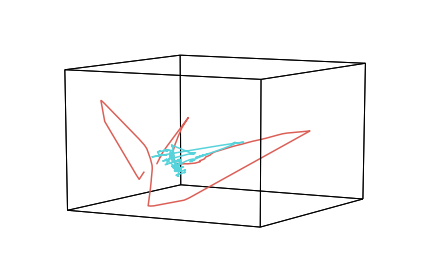

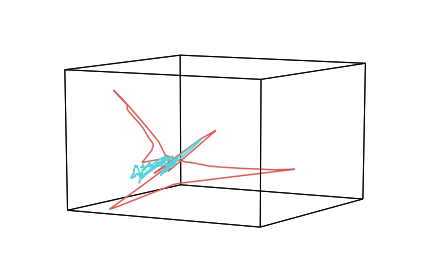

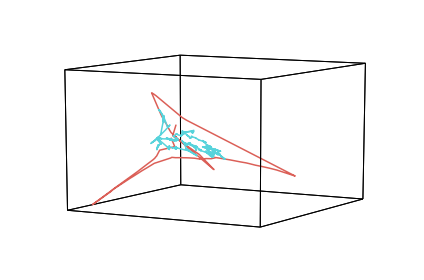

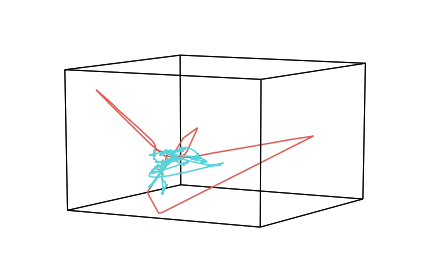

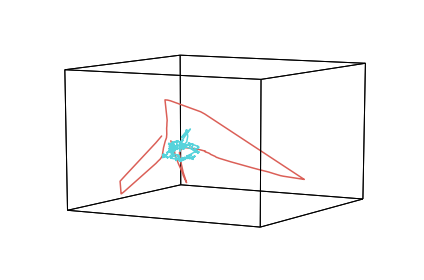

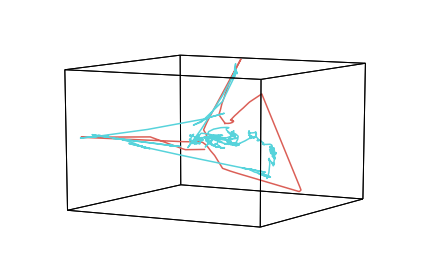

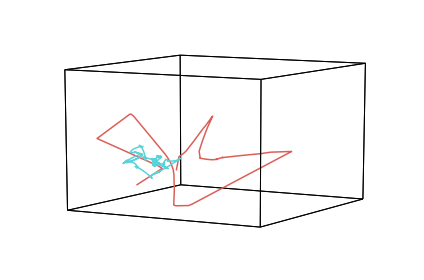

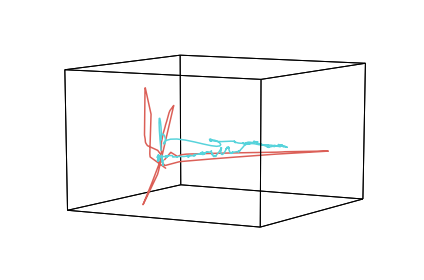

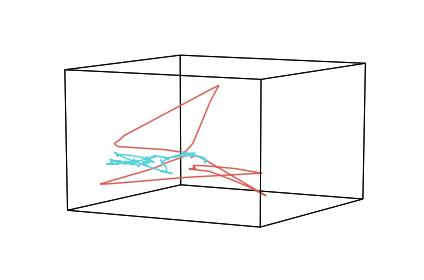

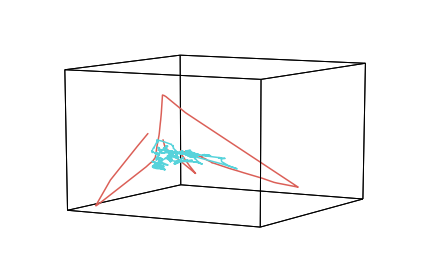

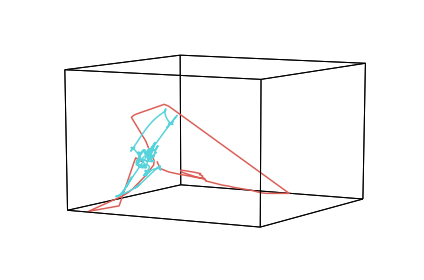

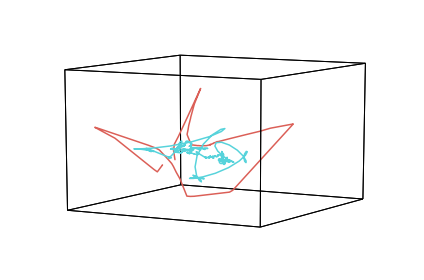

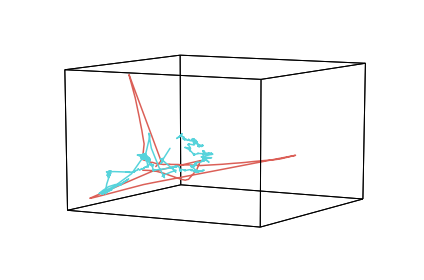

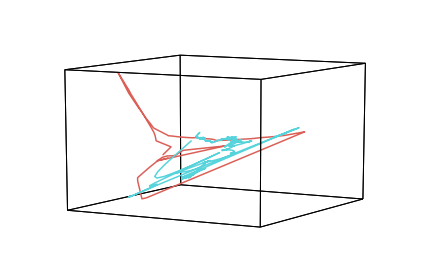

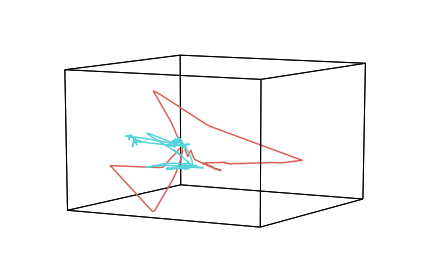

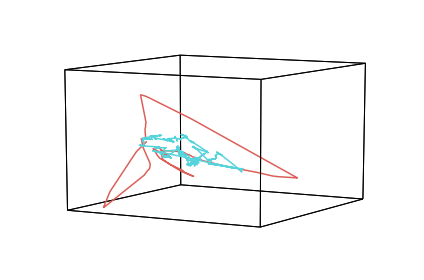

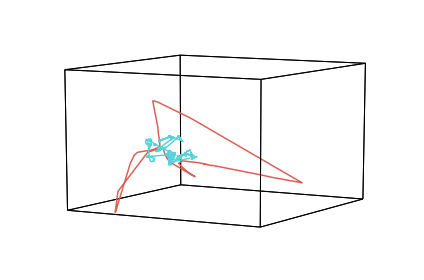

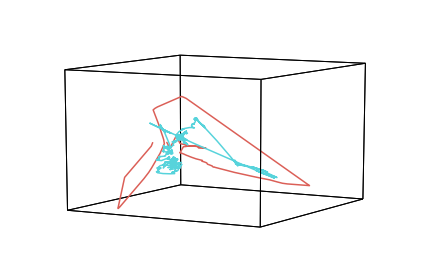

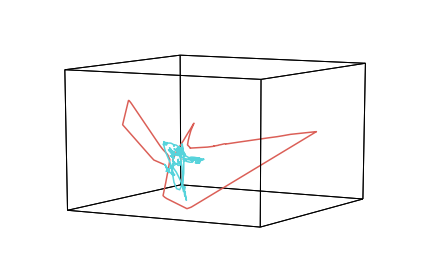

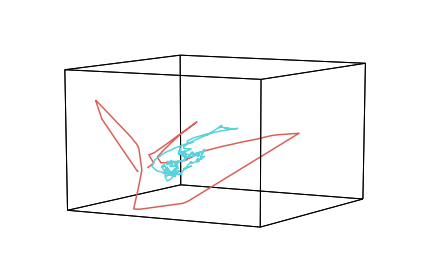

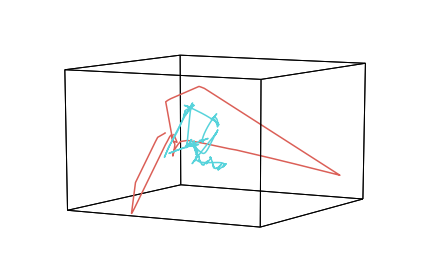

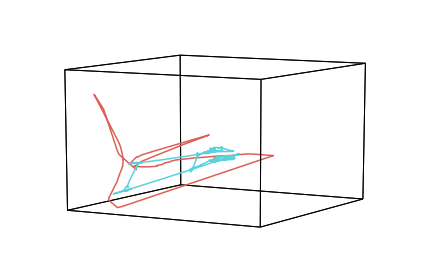

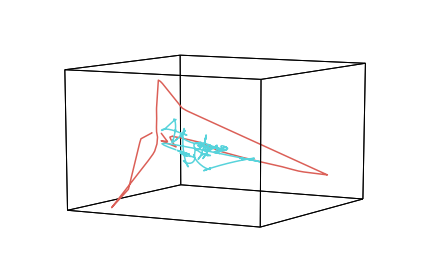

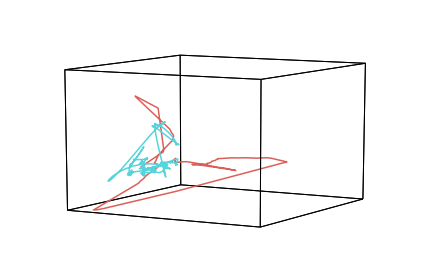

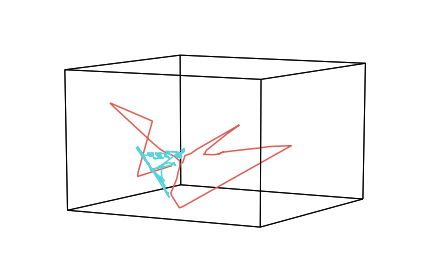

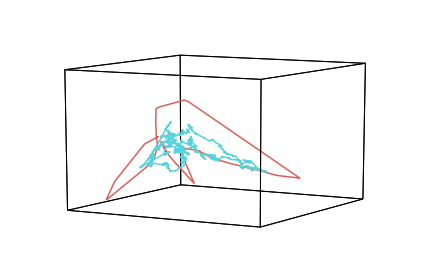

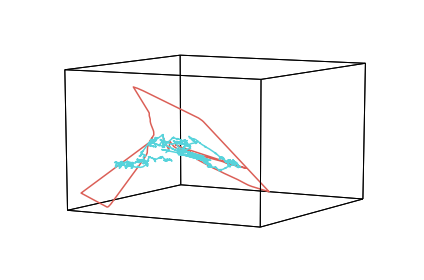

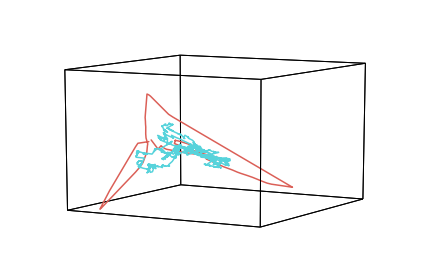

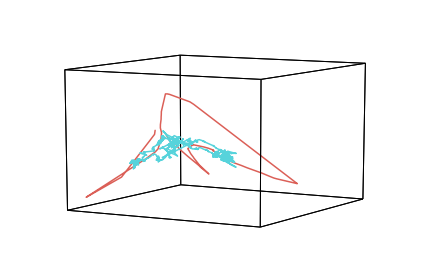

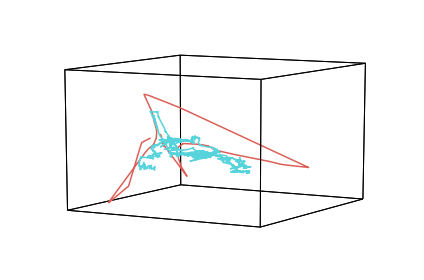

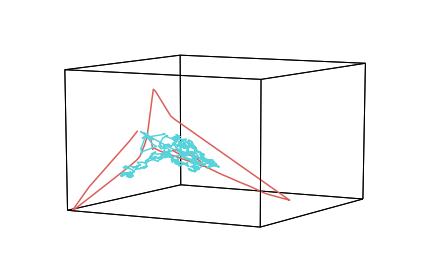

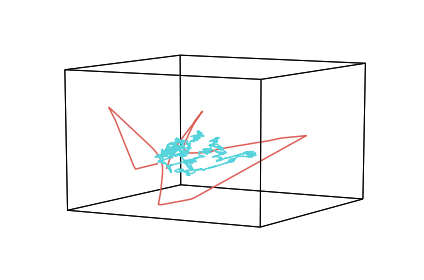

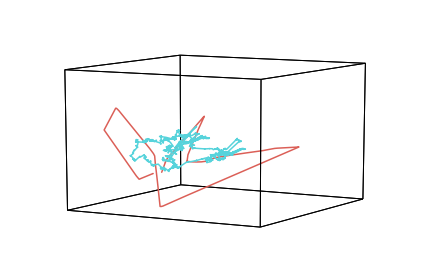

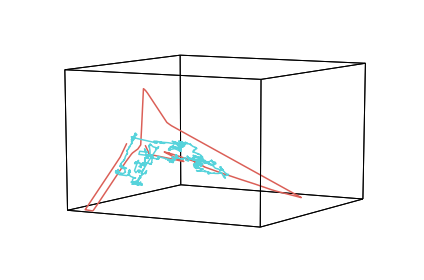

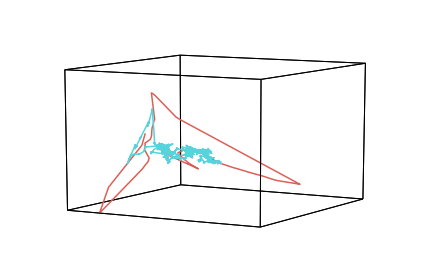

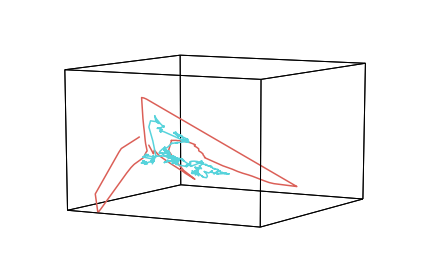

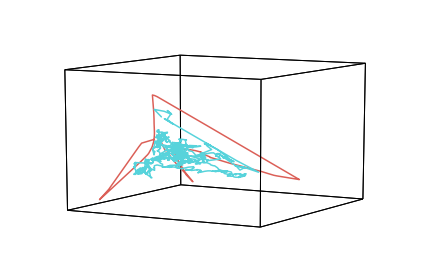

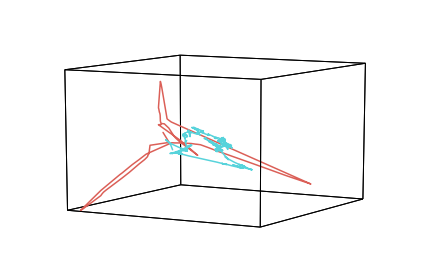

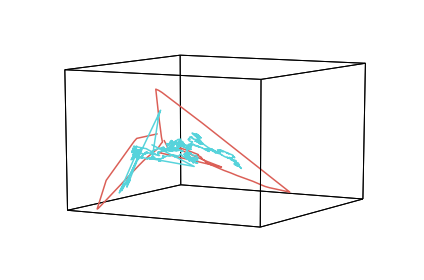

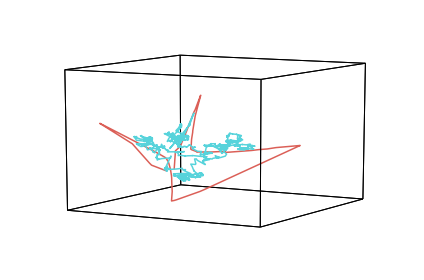

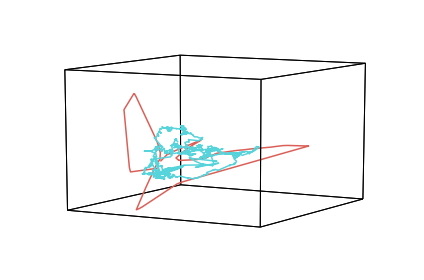

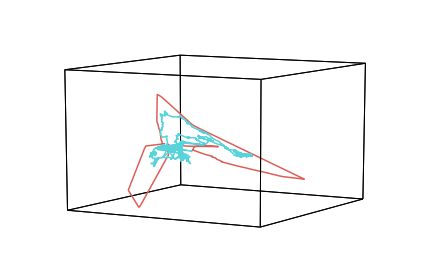

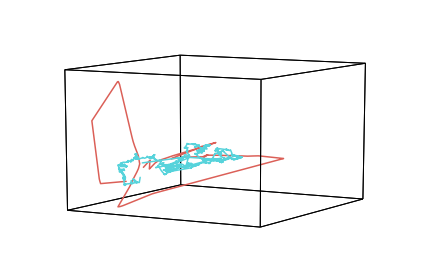

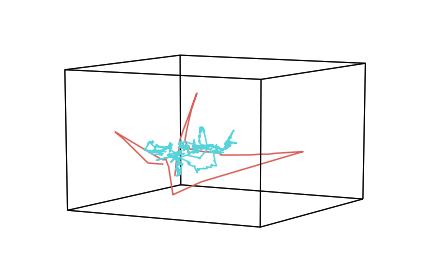

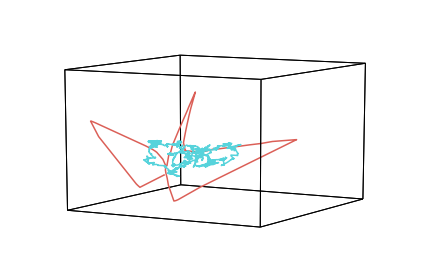

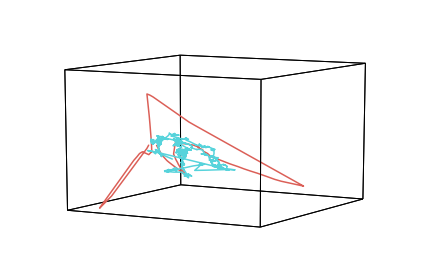

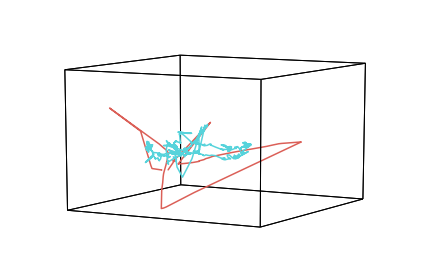

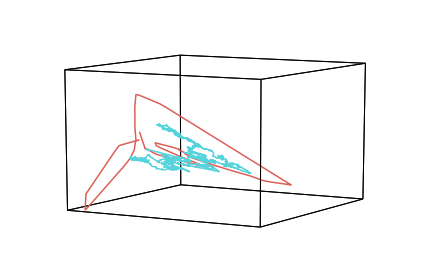

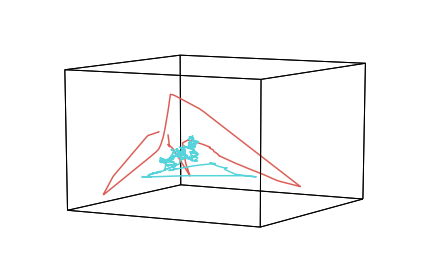

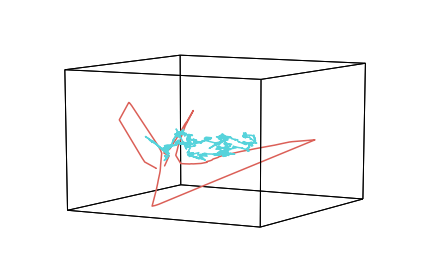

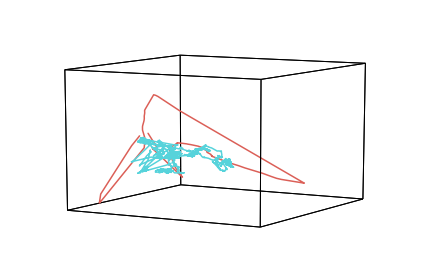

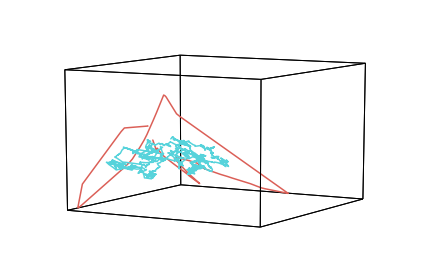

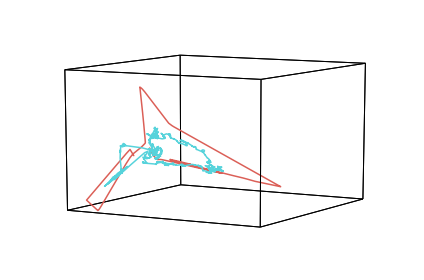

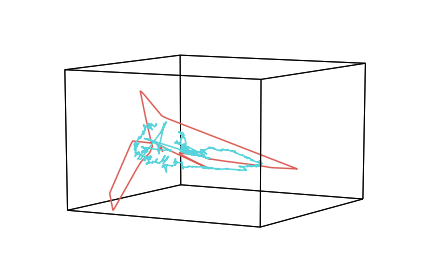

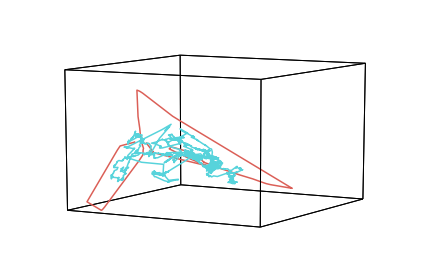

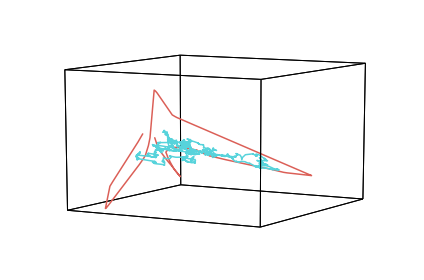

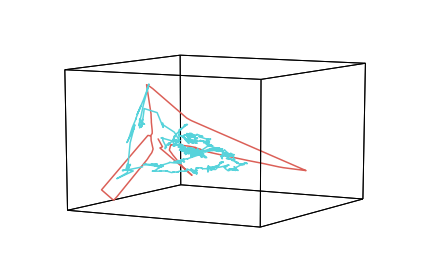

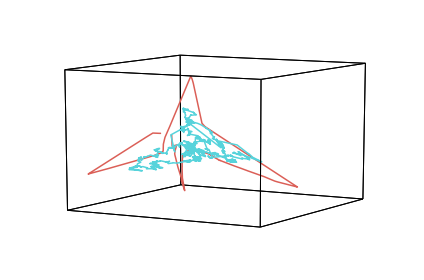

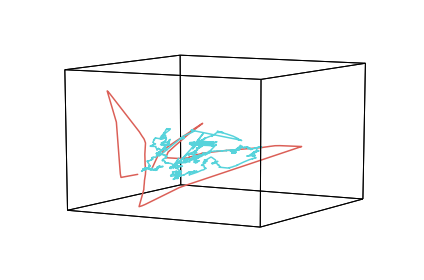

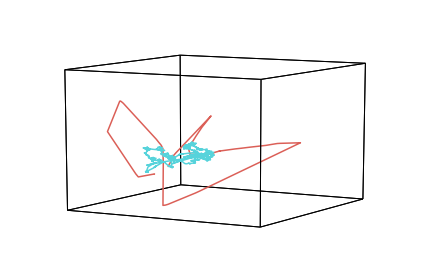

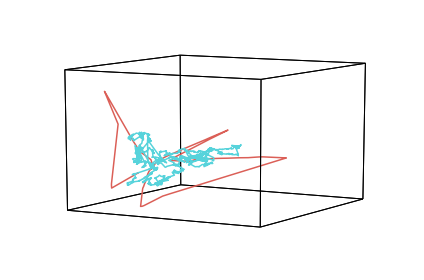

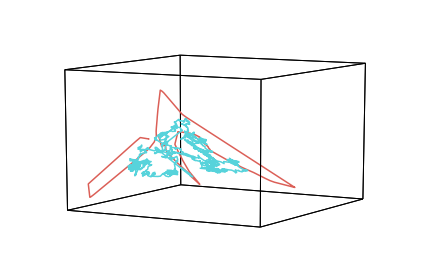

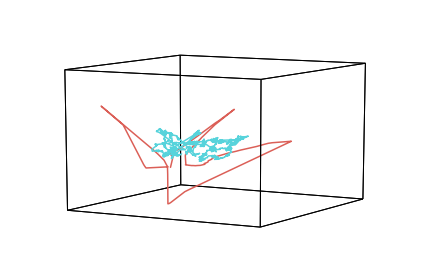

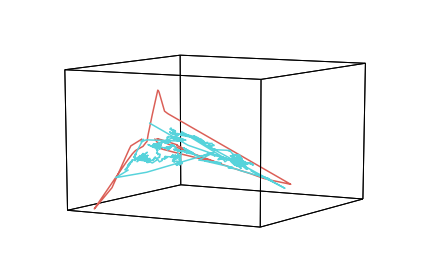

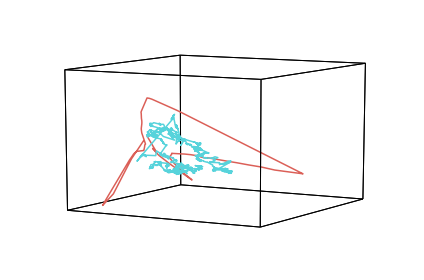

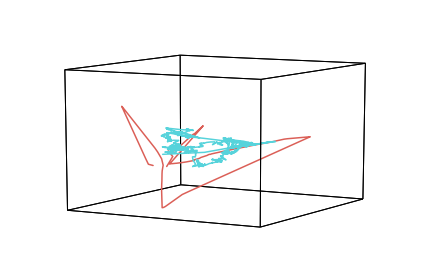

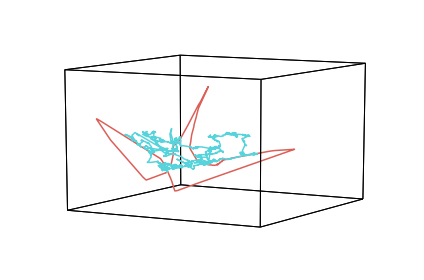

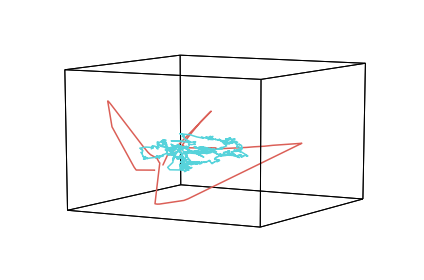

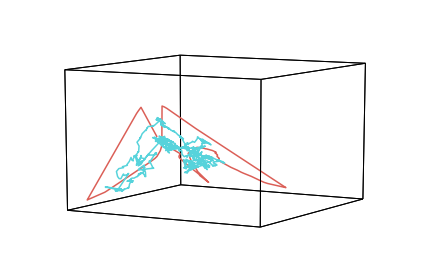

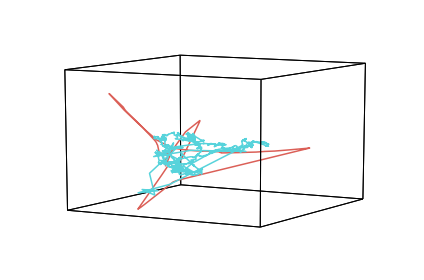

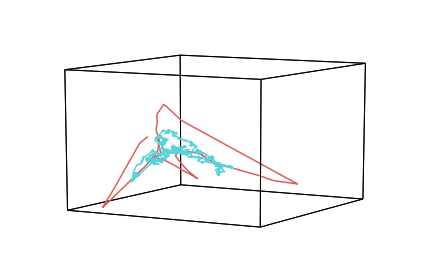

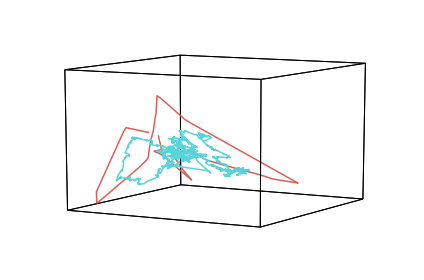

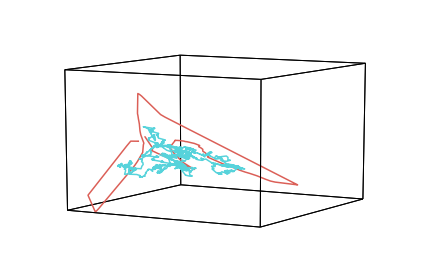

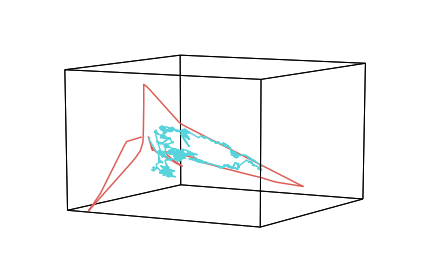

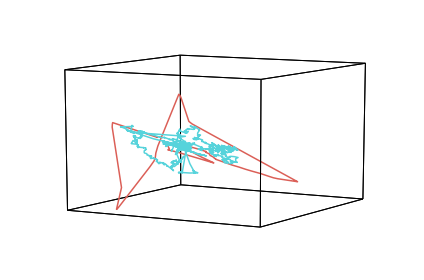

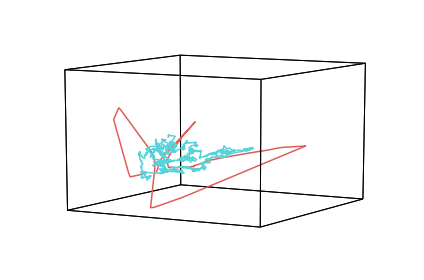

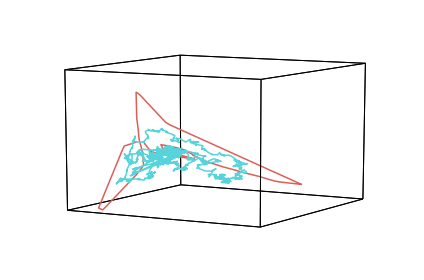

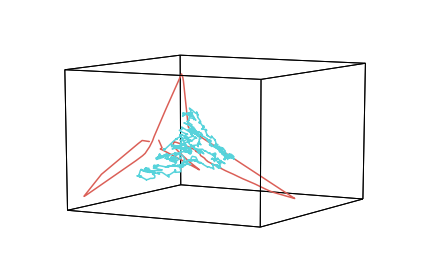

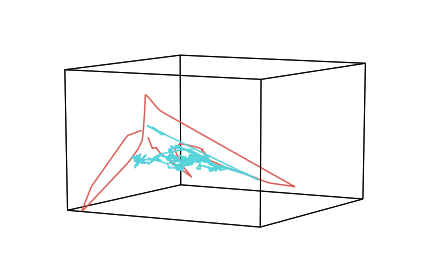

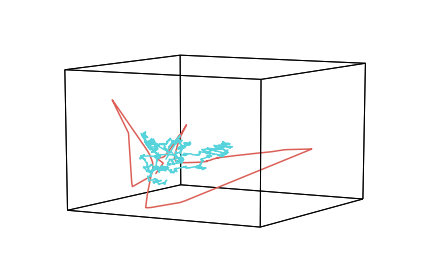

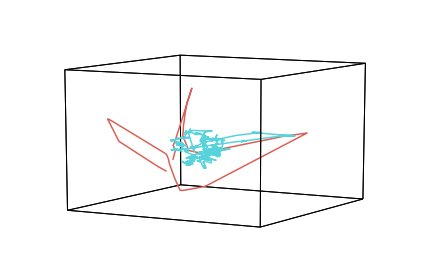

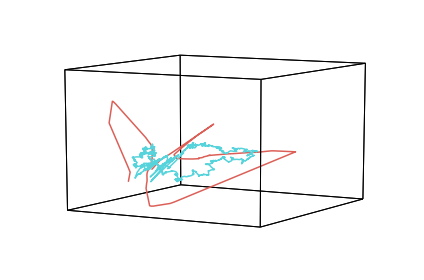

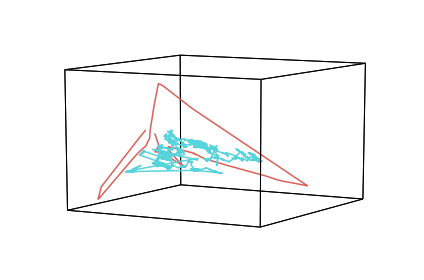

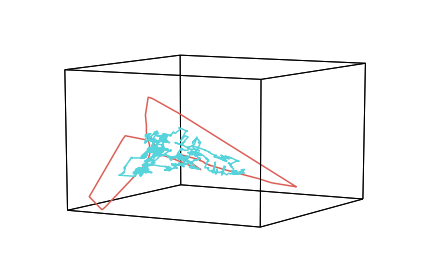

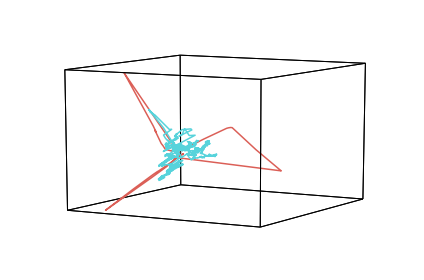

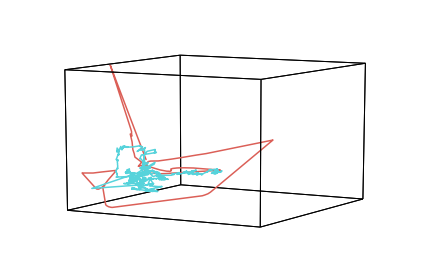

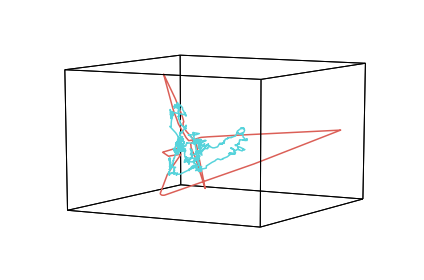

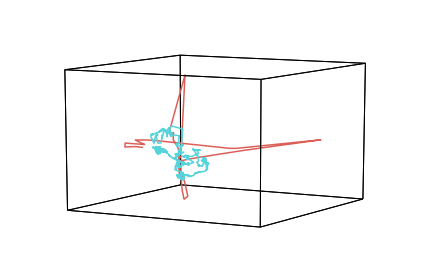

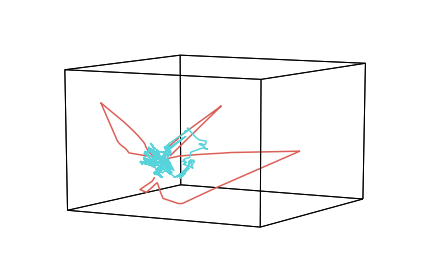

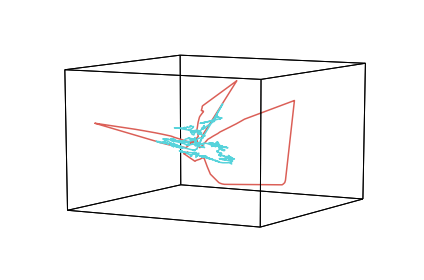

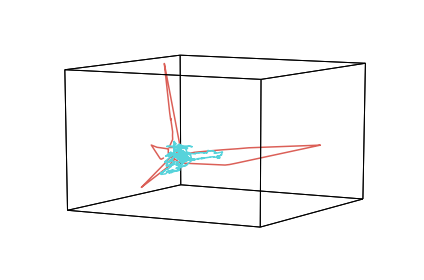

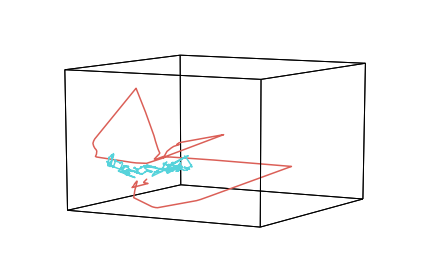

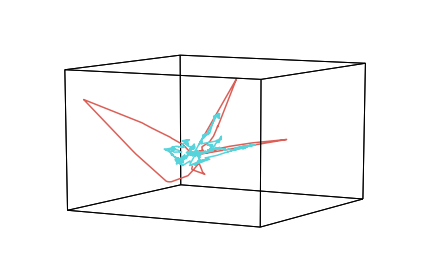

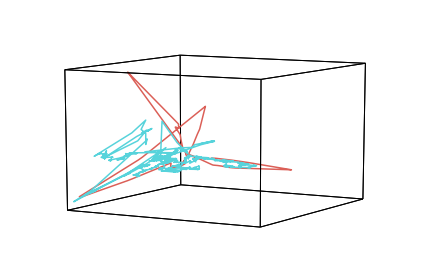

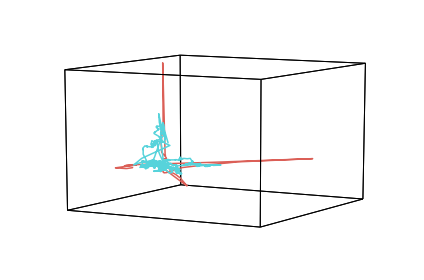

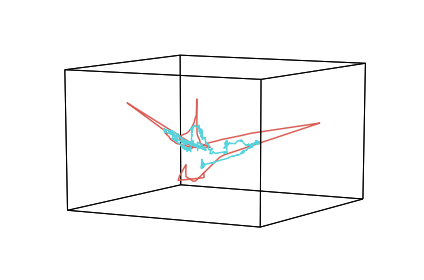

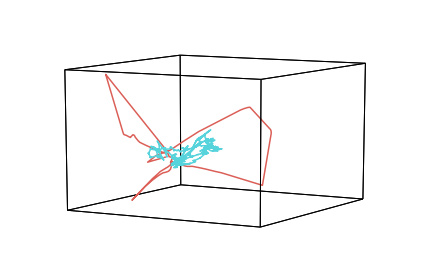

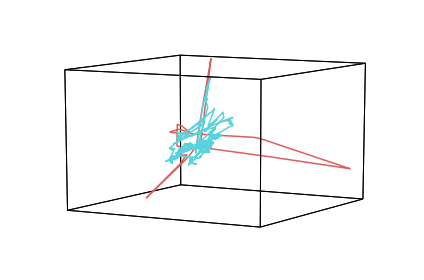

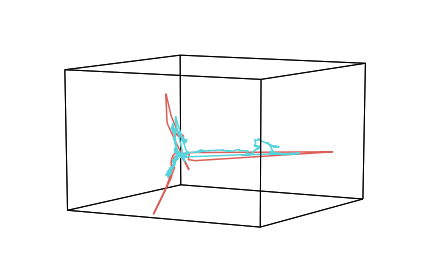

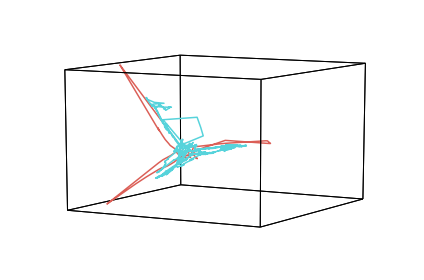

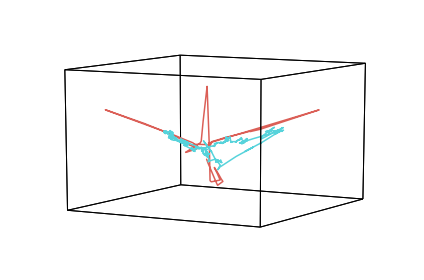

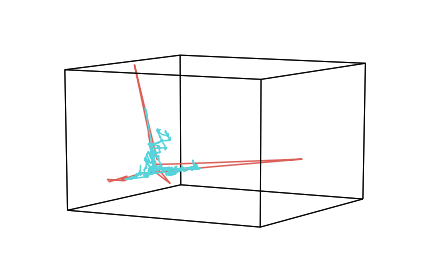

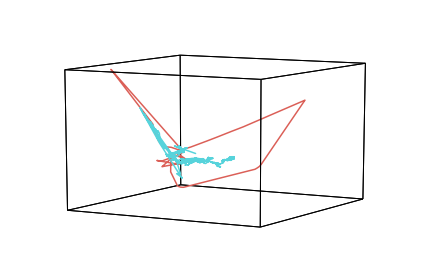

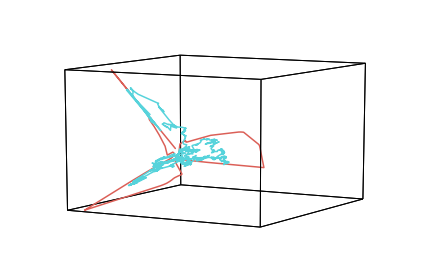

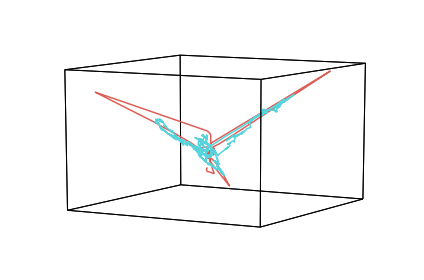

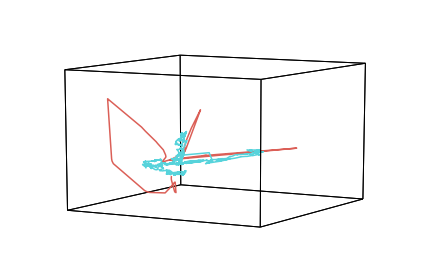

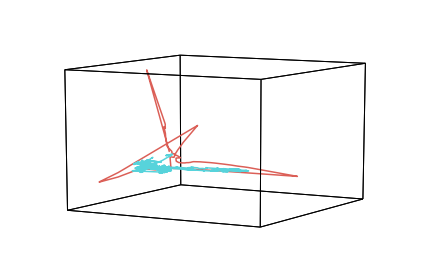

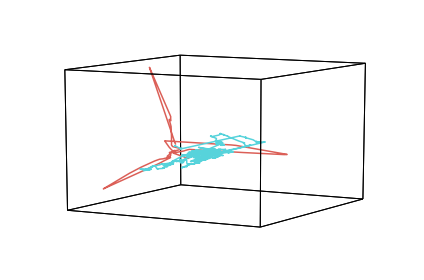

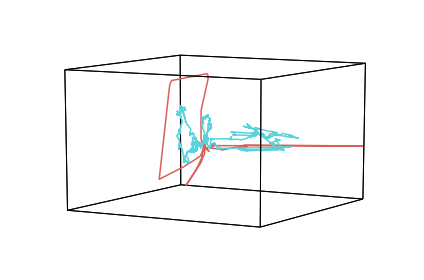

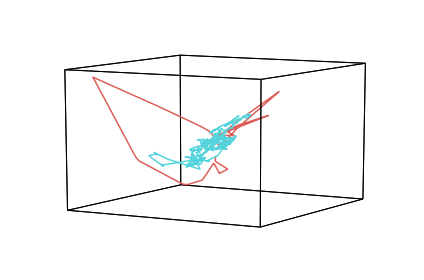

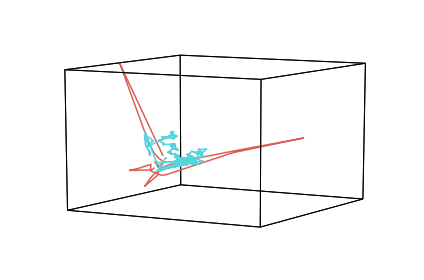

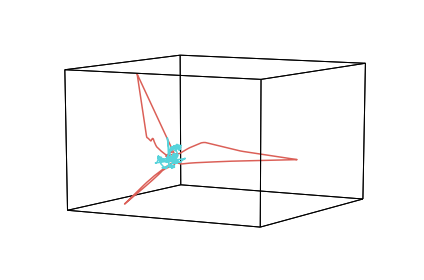

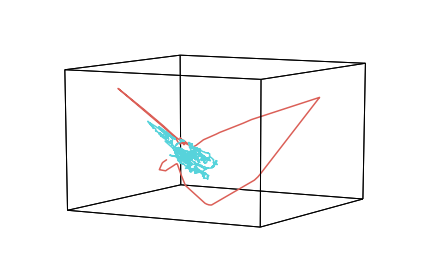

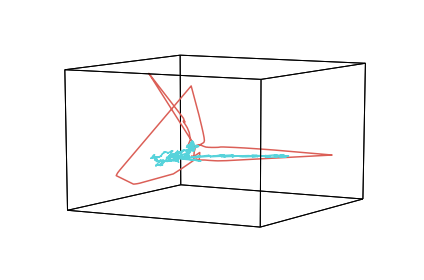

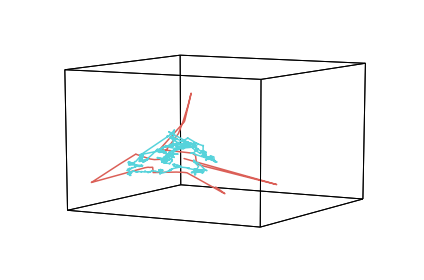

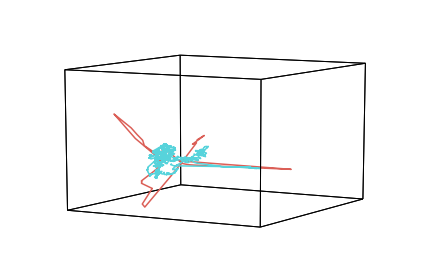

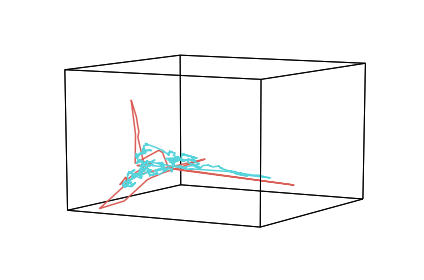

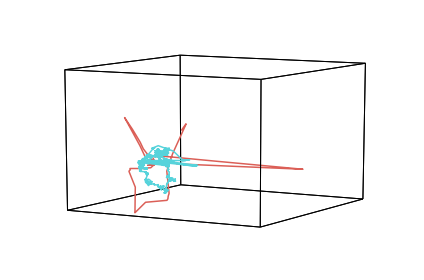

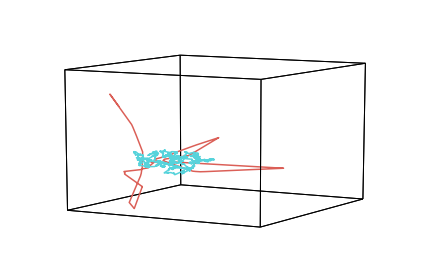

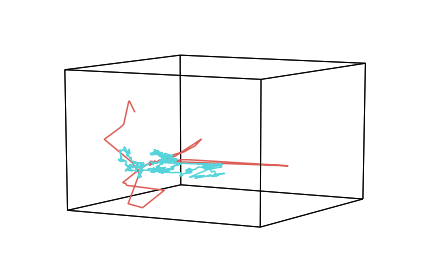

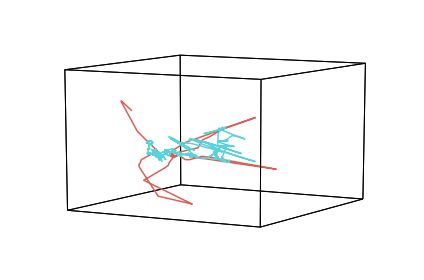

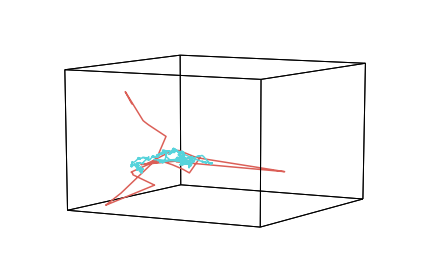

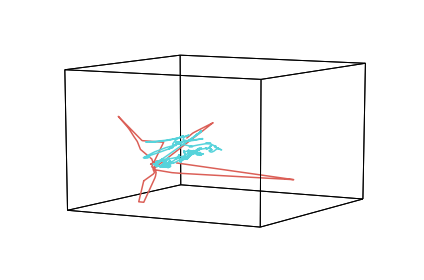

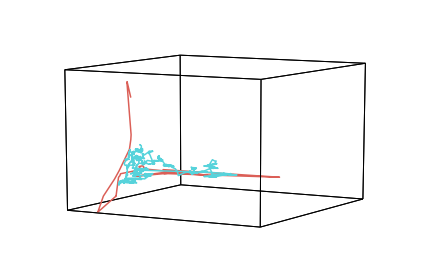

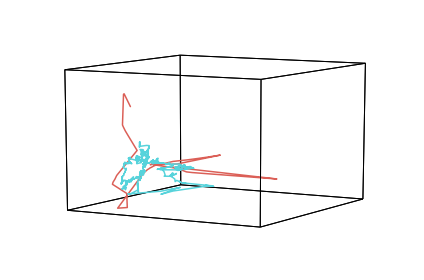

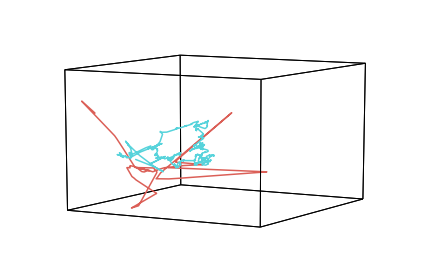

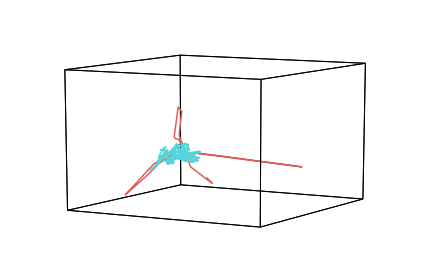

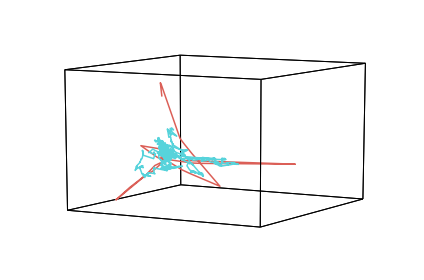

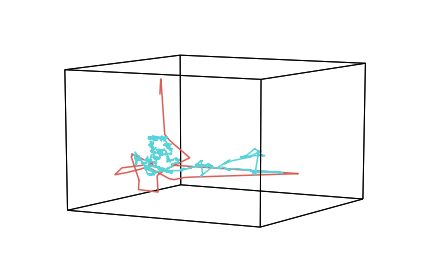

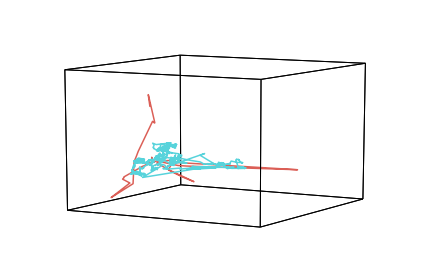

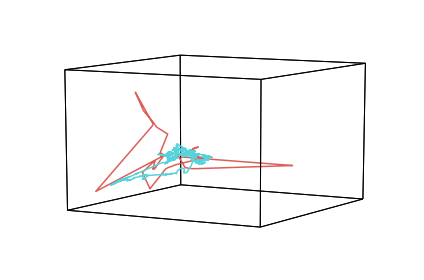

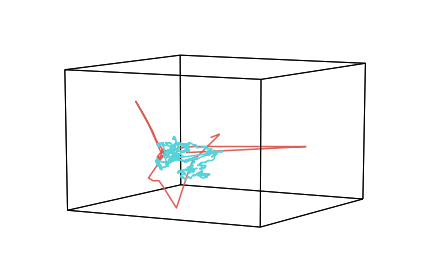

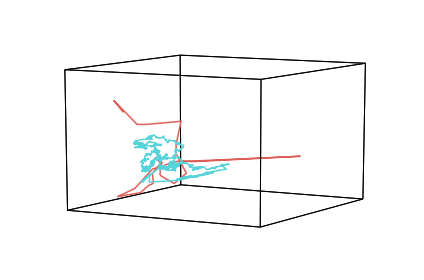

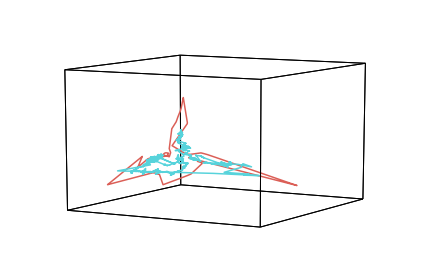

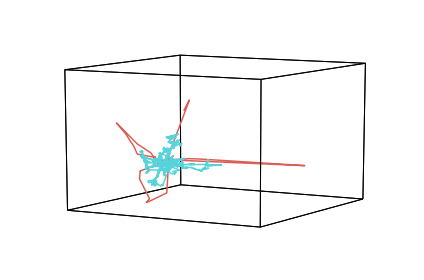

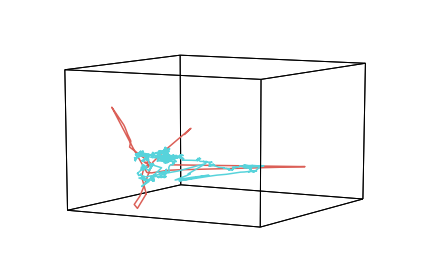

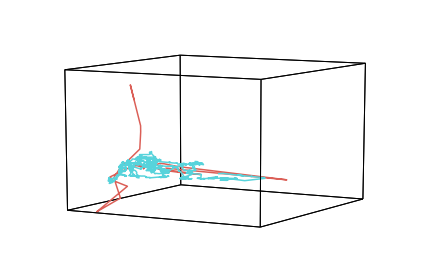

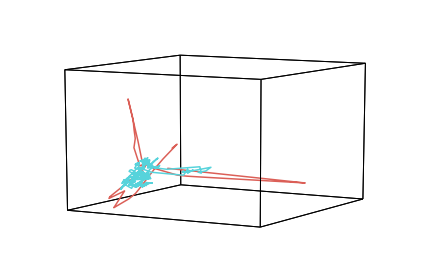

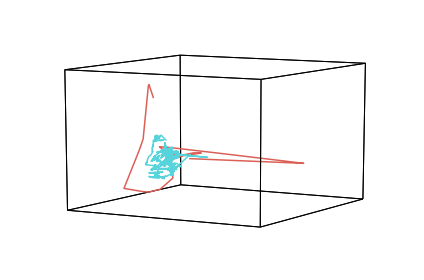

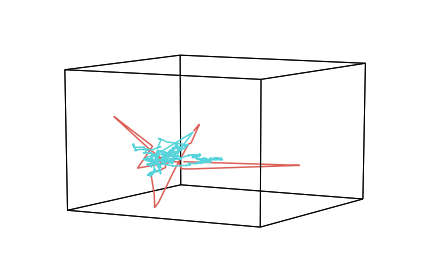

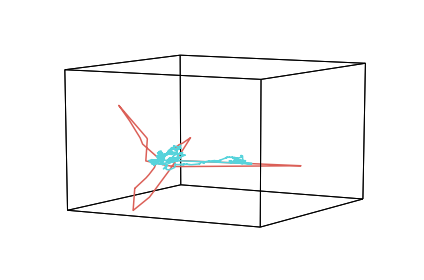

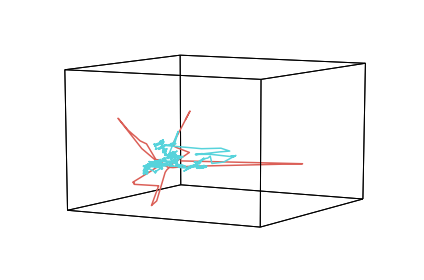

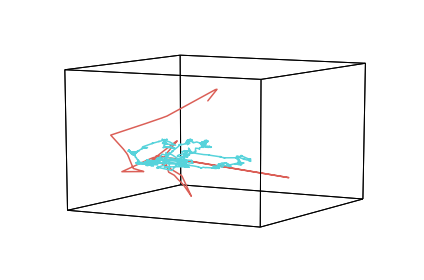

In [33]:
# old parameters
for ref, models in participant_trajectories.items():
    if ref =='atlep1' or ref == 'delayed' or ref == 'prediction':
        ep_mod = atlep1_traj
    elif ref == 'atlep2':
        ep_mod = atlep2_traj
    else:
        ep_mod = arrdev_traj
        
    for mod in models:
        hyp.plot([ep_mod, mod[1]])

In [34]:
# for ref, models in participant_trajectories.items():
#     if ref =='atlep1' or ref == 'delayed' or ref == 'prediction':
#         ep_mod = atlep1_traj_prop
#     elif ref == 'atlep2':
#         ep_mod = atlep2_traj_prop
#     else:
#         ep_mod = arrdev_traj_prop
        
#     for mod in models:
#         hyp.plot([ep_mod, mod[1]])

In [35]:
# for ref, models in participant_trajectories.items():
#     if ref =='atlep1' or ref == 'delayed' or ref == 'prediction':
#         ep_mod = atlep1_traj_prop
#     elif ref == 'atlep2':
#         ep_mod = atlep2_traj_prop
#     else:
#         ep_mod = arrdev_traj_prop
        
#     for mod in models:
#         hyp.plot([ep_mod, mod[1]])

## some stats

In [37]:
episode_trajectories = {'atlep1' : atlep1_traj, 'atlep2' : atlep2_traj, 'arrdev' : arrdev_traj, 
                        'delayed' : atlep1_traj, 'prediction' : atlep2_traj}

# episode_trajectories_prop = {'atlep1' : atlep1_traj_prop, 'atlep2' : atlep2_traj_prop, 'arrdev' : arrdev_traj_prop, 
#                         'delayed' : atlep1_traj_prop, 'prediction' : atlep2_traj_prop}

In [38]:
print('OLD PARAMETERS:\n')

for rectype in avg_trajectories.keys():
    euc_distance = np.mean(np.diag(cdist(avg_trajectories[rectype], episode_trajectories[rectype], 
                                   metric='euclidean')))
    corr = corr_mean(np.diag(1-cdist(avg_trajectories[rectype], episode_trajectories[rectype], 
                                   metric='correlation')))
    
    print(rectype + ':')
    print('\tmean Euclidean distance: ' + str(euc_distance))
    print('\tMean correlation: ' + str(corr))

OLD PARAMETERS:

atlep1:
	mean Euclidean distance: 0.6374093998977061
	Mean correlation: 0.6258087118040806
prediction:
	mean Euclidean distance: 0.8205622733521426
	Mean correlation: 0.06606548194092804
delayed:
	mean Euclidean distance: 0.6405685618013831
	Mean correlation: 0.621135578233648
atlep2:
	mean Euclidean distance: 0.7053860492799636
	Mean correlation: 0.463208005053915
arrdev:
	mean Euclidean distance: 0.7149211551436448
	Mean correlation: 0.46776793634727715


In [39]:
# print('UPDATED EPISODE WINDOW SIZE:\n')

# for rectype in avg_trajectories.keys():
#     euc_distance = np.mean(np.diag(cdist(avg_trajectories[rectype], episode_trajectories_prop[rectype], 
#                                    metric='euclidean')))
#     corr = corr_mean(np.diag(1-cdist(avg_trajectories[rectype], episode_trajectories_prop[rectype], 
#                                    metric='correlation')))
    
#     print(rectype + ':')
#     print('\tmean Euclidean distance: ' + str(euc_distance))
#     print('\tMean correlation: ' + str(corr))

In [40]:
# print('UPDATED EPISODE WINDOW SIZE & RECALL WINDOW SIZE:\n')

# for rectype in avg_trajectories.keys():
#     euc_distance = np.mean(np.diag(cdist(avg_trajectories[rectype], episode_trajectories_prop[rectype], 
#                                    metric='euclidean')))
#     corr = corr_mean(np.diag(1-cdist(avg_trajectories[rectype], episode_trajectories_prop[rectype], 
#                                    metric='correlation')))
    
#     print(rectype + ':')
#     print('\tmean Euclidean distance: ' + str(euc_distance))
#     print('\tMean correlation: ' + str(corr))

In [3]:
# with open('../../data/transcriptions/automatic/MD-021819-B-01/debug2LQvu:debugk4zJe\
# /debug2LQvu:debugk4zJe-recall-corrected.wav.txt', 'r') as f:
#     transcript = ' '.join([line.split(',')[0] for line in f.read().split('\n')])

In [4]:
# transcript

"SO THERE ARE THREE MEN COME OUT OF THE TRUCK AND THEY'RE PARKED IN FRONT OF WHAT WE LATER DISCOVERED AS A NIGHTCLUB BUT I THINK IT'S ALSO A RAINBOW VIDEO STATION LIKE A DINER SET UP SO THEY COME OUT INTO THE PARKING LOT COME ACROSS A COUPLE WE LATER FIND OUT THAT ONE OF THE MEN ONE OF THE MEN IN THE GROUP OF THREE WAS NICK ALFRED AND THE OTHER DARIUS NOT SURE WHAT THE THIRD GUY'S NAME WAS AND THEY COME ACROSS A COUPLE THERE'S SOME SORT OF CONFRONTATION SO ALFRED'S RAP NAME IS PAPER BOY AND THE THE BOYFRIEND OF THE COUPLE THAT THEY CROSS SAYS SOMETHING ABOUT HIS MUSIC NOT BEING GOOD SO ALFRED PULLS A GUN ON HIM AND I THINK THAT ALFRED'S CALM PATRIOT PULLS A GUN ON ALFRED AND TURN I THINK TO DETER HIM OR SOMETHING AND THE BOYFRIEND ALFRED HAD PULLED A GUN OUT ON LIFE'S A GUN AND SAYS THAT HE HAS FRIENDS WHO ARE IN THE AREA AND IF YOU WERE TO DO ANYTHING THAT HE BE QUIET AND AN AERIAL VIEW AND THEN IT TURNS TO THE TITLE SEQUENCE AND IT SHOWS RUN-DOWN HOMES AND SOME LIKE MCMANSION DEVELOP

In [19]:
atlep1_df.loc[306].values

array([22062, 882.48,
       'Dave tells him KP would want five hundred dollars to play the song.',
       'Dave is asking for a bribe to do Earn a favor', 'Dave, Earn',
       'no', 'Half a stack.', 'Dave', 'outdoor',
       'radio station parking lot',
       'Meeting Dave in the Radio Station Parking Lot'], dtype=object)